<a href="https://colab.research.google.com/github/ShadenAhmed/DataScience-Project/blob/main/DateScience_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Collecting Data
###Phase 1

In [ ]:
import yfinance as yf
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [ ]:

gold_symbol = "GC=F"
start_date = "2020-01-01"
end_date = "2026-1-31"

gold_raw_data = yf.download(gold_symbol, start=start_date, end=end_date)

print(gold_raw_data.head()) # first five days of 2020
print(gold_raw_data.tail()) # last available days in 2026

gold_raw_data.to_csv("gold_prices_2020-2026_raw.csv")


/tmp/ipython-input-454/1211144814.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_raw_data = yf.download(gold_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2020-01-02  1524.500000  1528.699951  1518.000000  1518.099976    214
2020-01-03  1549.199951  1552.699951  1530.099976  1530.099976    107
2020-01-06  1566.199951  1580.000000  1560.400024  1580.000000    416
2020-01-07  1571.800049  1576.300049  1558.300049  1558.300049     47
2020-01-08  1557.400024  1604.199951  1552.300049  1579.699951    236
Price             Close         High          Low         Open  Volume
Ticker             GC=F         GC=F         GC=F         GC=F    GC=F
Date                                                                  
2026-01-26  5079.700195  5095.600098  5052.200195  5081.500000     180
2026-01-27  5079.899902  5079.899902  5079.899902  5079.899902      34
2026-01-28  5301.600098  5301.600098  5301.600098  5301.600098  112054
2026-01-29  53

In [ ]:
!pip install gnews

from gnews import GNews
import pandas as pd

google_news = GNews(language='en',
                    start_date=(2020, 1, 1),
                    end_date=(2026, 1, 31))


news_results = google_news.get_news('gold price war conflict geopolitical')

formatted_news = []
for article in news_results:
    formatted_news.append({
        'published_date': article['published date'],
        'title': article['title'],
        'description': article['description'],
        'url': article['url']
    })

df_news = pd.DataFrame(formatted_news)

print(df_news[['published_date', 'title']].head())

df_news.to_csv("raw_gnews_data.csv", index=False)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 12.5 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=5844e5eecd203c3174deb6b0597298185b80cbf321cd1ab4bb8300312b01d69d
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k
                  published_date  \
0  Sat, 21 Jun 2025 07:00:00 GMT   
1  Wed, 29 Oct 2025 07:00:00 GMT   
2  Wed, 15 Nov 2023 08:00:00 GMT   
3  Wed, 02 Jul 2025 07:00:00 GMT   
4  Tue, 21 Nov 2023 08:00:00 GMT   

                                               title  
0  Gold prices should hit $4,000 as U.S. deficits...  
1  Geopolitics affirms gold as a key strategic as...  
2         The impact of wars on gold prices - 11Onze  
3  How Geopolitical Risk Drives Gold Prices - U.S...  
4  The price of g

#2. Data Processing and Cleaning
###Phase 2


## 2.1 Geopolitical news data

In [ ]:
#imports + read

import pandas as pd
import re
import matplotlib.pyplot as plt

df = pd.read_csv("raw_gnews_data.csv")

#inspect dataset

df.head()
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   published_date  76 non-null     object
 1   title           76 non-null     object
 2   description     76 non-null     object
 3   url             76 non-null     object
dtypes: object(4)
memory usage: 2.5+ KB


np.int64(0)

**Inspection result:** published_date is stored as object type and requires conversion to datetime. No missing values or duplicate rows were detected in the dataset.

In [ ]:
#cleaning the data

# published_date conversion to datetime
df["published_date"] = pd.to_datetime(df["published_date"], errors="coerce")

#Even though no duplicates or missing titles were found during the previous step,
#we still need to ensure the dataset is clean and reliable before further analysis.
df = df.drop_duplicates(subset=["title"])
df = df.dropna(subset=["title"])

#cleening the text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

#side by side comparison
df["title_clean"] = df["title"].apply(clean_text)
df["description_clean"] = df["description"].apply(clean_text)
df[["title", "title_clean", "description", "description_clean"]].head(3)

,title,title_clean,description,description_clean
0,"Gold prices should hit $4,000 as U.S. deficits...",gold prices should hit 4000 as us deficits may...,"Gold prices should hit $4,000 as U.S. deficits...",gold prices should hit 4000 as us deficits may...
1,Geopolitics affirms gold as a key strategic as...,geopolitics affirms gold as a key strategic as...,Geopolitics affirms gold as a key strategic as...,geopolitics affirms gold as a key strategic as...
2,The impact of wars on gold prices - 11Onze,the impact of wars on gold prices 11onze,The impact of wars on gold prices 11Onze,the impact of wars on gold prices 11onze


We will create a binary **event indicator** using specific keywords to identify geopolitical headlines, converting the news text into structured data that can be compared with gold price movements.

In [ ]:
#fearure engineering:
#convert unstucutured text to stucutured text by creating an event indicator

keywords = ["war", "conflict", "invasion", "attack",
            "sanction", "military", "tension", "crisis","crises"]

def detect_event(text):
    return 1 if any(word in text for word in keywords) else 0
df["event_indicator"] = df["title_clean"].apply(detect_event)
df["event_indicator"].value_counts()

#a monthgly event count
df["year_month"] = df["published_date"].dt.to_period("M")
monthly_events = df.groupby("year_month")["event_indicator"].sum()

monthly_events

,event_indicator
year_month,
2020-01,1
2023-10,2
2023-11,2
2024-01,2
2024-02,0
2024-03,1
2024-04,1
2024-06,0
2024-09,2


News events will be organized by **month** to identify periods of higher geopolitical activity:

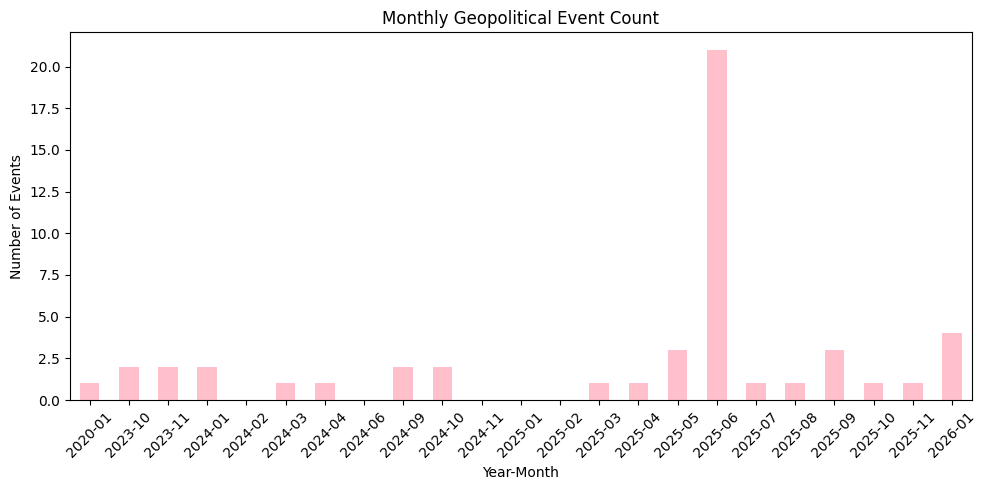

,event_indicator
year_month,
2025-06,21
2026-01,4
2025-05,3
2025-09,3
2023-10,2


In [ ]:
#organize event timelines

#sort by date
df = df.sort_values("published_date")
df[["published_date", "title", "event_indicator"]].head()

#draw barplot
monthly_events.plot(kind="bar", figsize=(10,5), color="pink")
plt.title("Monthly Geopolitical Event Count")
plt.xlabel("Year-Month")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#high activity months - event clusters
monthly_events.sort_values(ascending=False).head(5)

 A significant spike was observed in **June 2025**, indicating a strong event cluster that can be compared with gold price behavior.

To better understand the dominant themes in the geopolitical news dataset, a word frequency analysis will be conducted on the cleaned headlines:

In [ ]:
#word freq. analysis

from collections import Counter

all_words = " ".join(df["title_clean"]).split()
word_counts = Counter(all_words)

pd.DataFrame(word_counts.most_common(15), columns=["Word", "Count"])

,Word,Count
0,gold,75
1,the,34
2,prices,24
3,geopolitical,21
4,conflict,18
5,discovery,18
6,alert,18
7,price,17
8,israeliran,16
9,and,15


In [ ]:
#save clean dataset

clean_news_data = df[[
    "published_date",
    "title_clean",
    "description_clean",
    "event_indicator",
    "year_month"
]].copy()

clean_news_data.to_csv("clean_news_data.csv", index=False)

print("Clean dataset saved:", clean_news_data.shape)

Clean dataset saved: (76, 5)


##2.2 Gold prices data


In [ ]:
import pandas as pd

df = pd.read_csv("gold_prices_2020-2026_raw.csv")
#Initial Inspection
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1532 entries, 0 to 1531
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1532 non-null   object
 1   Close   1531 non-null   object
 2   High    1531 non-null   object
 3   Low     1531 non-null   object
 4   Open    1531 non-null   object
 5   Volume  1531 non-null   object
dtypes: object(6)
memory usage: 71.9+ KB


,Price,Close,High,Low,Open,Volume
count,1532,1531,1531,1531,1531,1531
unique,1532,1405,1386,1388,1395,883
top,2026-01-30,1815.9000244140625,1813.5,1784.0,1794.300048828125,6
freq,1,4,4,4,4,10


In [ ]:
#Renaming Columns
df.rename(columns={'Price': 'Date'}, inplace=True)
df.head()

,Date,Close,High,Low,Open,Volume
0,Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-01-02,1524.5,1528.699951171875,1518.0,1518.0999755859375,214
3,2020-01-03,1549.199951171875,1552.699951171875,1530.0999755859375,1530.0999755859375,107
4,2020-01-06,1566.199951171875,1580.0,1560.4000244140625,1580.0,416


In [ ]:
#Removing Metadata Rows
df = df.iloc[2:].reset_index(drop=True)
df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,1524.5,1528.699951171875,1518.0,1518.0999755859375,214
1,2020-01-03,1549.199951171875,1552.699951171875,1530.0999755859375,1530.0999755859375,107
2,2020-01-06,1566.199951171875,1580.0,1560.4000244140625,1580.0,416
3,2020-01-07,1571.800048828125,1576.300048828125,1558.300048828125,1558.300048828125,47
4,2020-01-08,1557.4000244140625,1604.199951171875,1552.300048828125,1579.699951171875,236


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
#Converting Data Types
numeric_cols = ['Close','High','Low','Open','Volume']
df[numeric_cols] = df[numeric_cols].astype(float)
df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214.0
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0


In [ ]:
#Removing Duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [ ]:
#Sorting by Date
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

In [ ]:
#Calculate daily returns
df['Daily_Return'] = df['Close'].pct_change()
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return
0,2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214.0,NaN
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161


In [ ]:
#Compute daily volatility
df['Volatility'] = df['High'] - df['Low']
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility
0,2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214.0,NaN,10.699951
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202,22.599976
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973,19.599976
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576,18.000000
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161,51.899902


In [ ]:
#Add new variable (Year) from the Date column
df['Year'] = df['Date'].dt.year
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility,Year
0,2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214.0,NaN,10.699951,2020
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202,22.599976,2020
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973,19.599976,2020
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576,18.000000,2020
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161,51.899902,2020


In [ ]:
#Handling Missing Values
df.isnull().sum()
df.dropna(inplace=True)
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility,Year
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202,22.599976,2020
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973,19.599976,2020
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576,18.000000,2020
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161,51.899902,2020
5,2020-01-09,1551.699951,1555.699951,1543.300049,1555.699951,54.0,-0.003660,12.399902,2020


In [ ]:
#Outliers analyzing
Q1 = df['Daily_Return'].quantile(0.25)
Q3 = df['Daily_Return'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Daily_Return'] < Q1 - 1.5*IQR) |
              (df['Daily_Return'] > Q3 + 1.5*IQR)]

In [ ]:
#Saved cleaned and processed dataset
df.to_csv("gold_prices_cleaned.csv", index=False)


## 2.3 Exploratory Data Analysis (EDA)

In [1]:
# ==================================================================================
# EXPLORATORY DATA ANALYSIS - GOLD PRICES & GEOPOLITICAL EVENTS
# ==================================================================================


#1. INTRODUCTION
#
#Performing Exploratory Data Analysis (EDA) on:
#
# **Primary Data:** Gold price data from 2020-2026
# - Price trends over time
# - Daily returns distribution and patterns
# - Volatility analysis
# - Correlation between market metrics
# - Identification of extreme events and anomalies
#
# **Secondary Data:** Geopolitical news headlines from 2020-2026
# - News frequency and patterns
# - Event type distribution
# - Text analysis of news content
# - Timeline of geopolitical events
#
# **Integrated Analysis:** Combining both datasets
# - Impact of events on gold prices
# - Volatility changes around events
# - Return patterns on event vs non-event days

In [ ]:

#2. IMPORT LIBRARIES

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import norm, skew, kurtosis, zscore

# Text analysis
import re
from wordcloud import WordCloud
from collections import Counter

# Date handling
from datetime import datetime

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set professional visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1.5

print("All libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

All libraries imported successfully
Pandas version: 2.2.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2


In [ ]:

#3. PRIMARY DATA EDA - GOLD PRICES


#3.1 Load and Inspect Gold Data
# Load gold dataset
gold_df = pd.read_csv('gold_prices_cleaned.csv')

# Convert Date column to datetime
gold_df['Date'] = pd.to_datetime(gold_df['Date'])

print("="*80)
print("GOLD PRICES DATASET OVERVIEW")
print("="*80)
print(f"\nDataset Shape: {gold_df.shape[0]:,} rows, {gold_df.shape[1]} columns")
print(f"Date Range: {gold_df['Date'].min()} to {gold_df['Date'].max()}")
print(f"Time Span: {(gold_df['Date'].max() - gold_df['Date'].min()).days:,} days")
print(f"Years Covered: {sorted(gold_df['Year'].unique())}")

print("\n" + "="*80)
print("FIRST 5 ROWS")
print("="*80)
gold_df.head()

GOLD PRICES DATASET OVERVIEW

Dataset Shape: 1,529 rows, 9 columns
Date Range: 2020-01-03 00:00:00 to 2026-01-30 00:00:00
Time Span: 2,219 days
Years Covered: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

FIRST 5 ROWS


,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility,Year
0,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202,22.599976,2020
1,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973,19.599976,2020
2,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576,18.000000,2020
3,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161,51.899902,2020
4,2020-01-09,1551.699951,1555.699951,1543.300049,1555.699951,54.0,-0.003660,12.399902,2020


In [ ]:

print("="*80)
print("DATA TYPES AND MEMORY USAGE")
print("="*80)
gold_df.info()

print("\n" + "="*80)
print("MISSING VALUES CHECK")
print("="*80)
missing = gold_df.isnull().sum()
if missing.sum() == 0:
    print("No missing values found in gold dataset")
else:
    print(missing[missing > 0])

DATA TYPES AND MEMORY USAGE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          1529 non-null   datetime64[ns]
 1   Close         1529 non-null   float64       
 2   High          1529 non-null   float64       
 3   Low           1529 non-null   float64       
 4   Open          1529 non-null   float64       
 5   Volume        1529 non-null   float64       
 6   Daily_Return  1529 non-null   float64       
 7   Volatility    1529 non-null   float64       
 8   Year          1529 non-null   int64         
dtypes: datetime64[ns](1), float64(7), int64(1)
memory usage: 107.6 KB

MISSING VALUES CHECK
No missing values found in gold dataset


In [ ]:

#3.2 Statistical Summary of Gold Data

print("="*80)
print("COMPREHENSIVE STATISTICAL SUMMARY")
print("="*80)

# Separate statistics for different types of columns
price_cols = ['Close', 'Open', 'High', 'Low']
return_cols = ['Daily_Return']
volatility_cols = ['Volatility']
volume_cols = ['Volume']

print("\nPRICE STATISTICS (USD):")
print("-" * 40)
price_stats = gold_df[price_cols].describe().round(2)
print(price_stats)

print("\nRETURN STATISTICS (%):")
print("-" * 40)
return_stats = gold_df['Daily_Return'].describe().round(4) * 100
print(return_stats)

print("\nVOLATILITY STATISTICS (USD):")
print("-" * 40)
vol_stats = gold_df['Volatility'].describe().round(2)
print(vol_stats)

print("\nVOLUME STATISTICS:")
print("-" * 40)
volume_stats = gold_df['Volume'].describe().round(0)
print(volume_stats)

COMPREHENSIVE STATISTICAL SUMMARY

PRICE STATISTICS (USD):
----------------------------------------
         Close     Open     High      Low
count  1529.00  1529.00  1529.00  1529.00
mean   2225.79  2225.18  2237.96  2213.07
std     701.85   701.95   708.63   695.04
min    1477.30  1469.30  1484.00  1452.10
25%    1796.40  1794.30  1804.20  1787.30
50%    1922.10  1922.60  1929.40  1913.70
75%    2415.00  2417.50  2429.00  2395.50
max    5318.40  5415.70  5586.20  5301.60

RETURN STATISTICS (%):
----------------------------------------
count    152900.00
mean          0.08
std           1.12
min         -11.37
25%          -0.44
50%           0.11
75%           0.68
max           5.95
Name: Daily_Return, dtype: float64

VOLATILITY STATISTICS (USD):
----------------------------------------
count    1529.00
mean       24.89
std        30.84
min         0.00
25%        10.70
50%        18.60
75%        31.60
max       740.50
Name: Volatility, dtype: float64

VOLUME STATISTICS:
----------

In [ ]:

#3.3 Advanced Statistical Measures

print("="*80)
print("ADVANCED STATISTICAL MEASURES")
print("="*80)

# Calculate advanced statistics
returns = gold_df['Daily_Return'].dropna() * 100

advanced_stats = {
    'Mean Return (%)': returns.mean(),
    'Median Return (%)': returns.median(),
    'Standard Deviation (%)': returns.std(),
    'Variance': returns.var(),
    'Skewness': skew(returns),
    'Kurtosis': kurtosis(returns),
    'Minimum Return (%)': returns.min(),
    'Maximum Return (%)': returns.max(),
    'Range (%)': returns.max() - returns.min(),
    'Positive Days (%)': (returns > 0).mean() * 100,
    'Negative Days (%)': (returns < 0).mean() * 100,
    'Zero Days (%)': (returns == 0).mean() * 100
}

for key, value in advanced_stats.items():
    print(f"{key}: {value:.4f}")

# Normality test
statistic, p_value = stats.shapiro(returns.sample(min(500, len(returns))))
print(f"\nShapiro-Wilk Normality Test:")
print(f"   Statistic: {statistic:.4f}")
print(f"   P-value: {p_value:.4f}")
print(f"   Conclusion: {'Not normal' if p_value < 0.05 else 'Normal'} distribution")

ADVANCED STATISTICAL MEASURES
Mean Return (%): 0.0802
Median Return (%): 0.1062
Standard Deviation (%): 1.1243
Variance: 1.2640
Skewness: -0.8974
Kurtosis: 9.5300
Minimum Return (%): -11.3662
Maximum Return (%): 5.9477
Range (%): 17.3139
Positive Days (%): 55.6573
Negative Days (%): 44.1465
Zero Days (%): 0.1962

Shapiro-Wilk Normality Test:
   Statistic: 0.9743
   P-value: 0.0000
   Conclusion: Not normal distribution


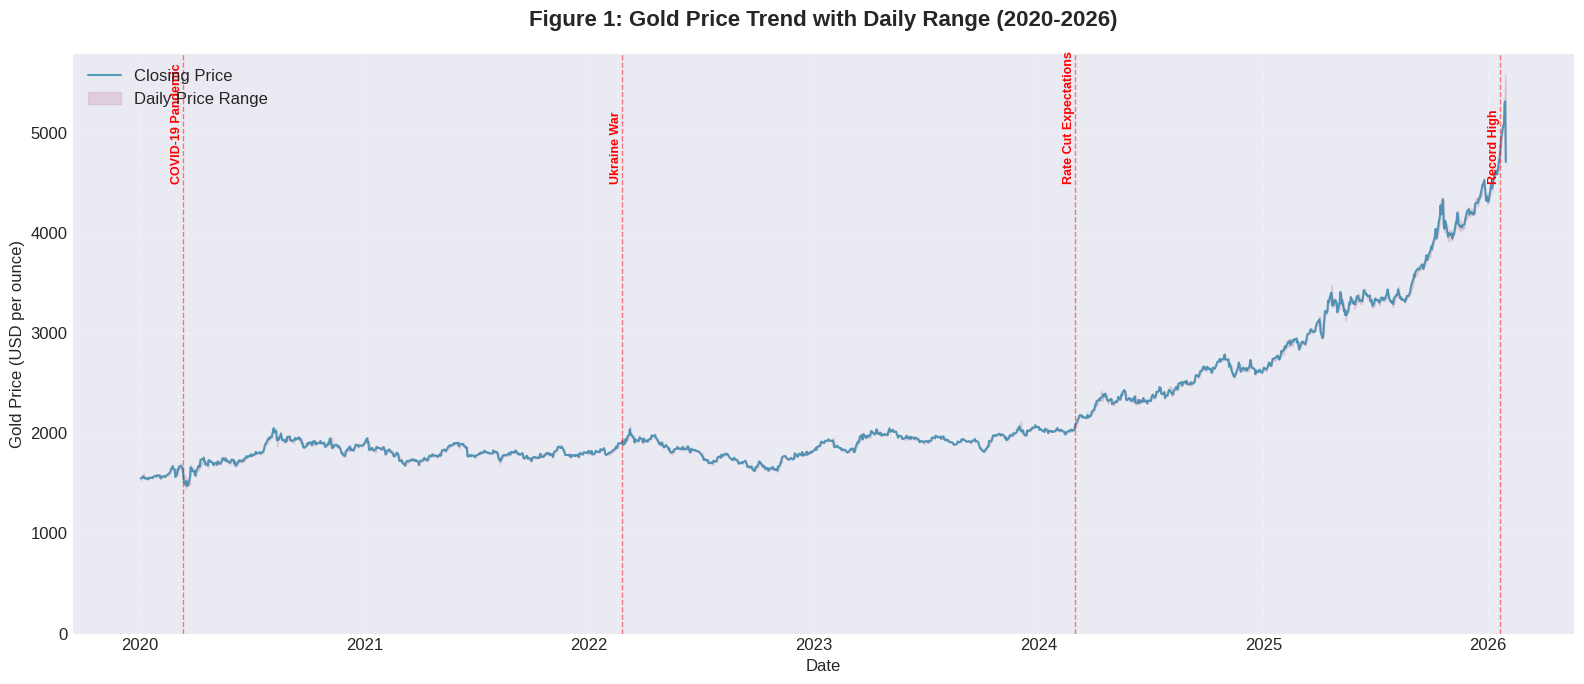

In [ ]:

#3.4 Gold Price Trend Analysis

# FIGURE 1: Gold Price Over Time with Daily Range
fig, ax = plt.subplots(figsize=(16, 7))

# Plot closing price
ax.plot(gold_df['Date'], gold_df['Close'], color='#2E86AB', linewidth=1.5, alpha=0.8, label='Closing Price')

# Fill between High and Low to show daily range
ax.fill_between(gold_df['Date'], gold_df['Low'], gold_df['High'],
                alpha=0.15, color='#A23B72', label='Daily Price Range')

# Add annotations for major events
major_events = {
    '2020-03-11': 'COVID-19 Pandemic',
    '2022-02-24': 'Ukraine War',
    '2023-10-07': 'Israel-Gaza Conflict',
    '2024-03-01': 'Rate Cut Expectations',
    '2026-01-20': 'Record High'
}

for date, label in major_events.items():
    event_date = pd.to_datetime(date)
    if event_date in gold_df['Date'].values:
        ax.axvline(x=event_date, color='red', alpha=0.5, linestyle='--', linewidth=1)
        ax.text(event_date, gold_df['Close'].max()*0.85, label,
                rotation=90, fontsize=9, color='red', ha='right', weight='bold')

ax.set_title('Figure 1: Gold Price Trend with Daily Range (2020-2026)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Gold Price (USD per ounce)', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper left')
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('fig1_gold_price_trend.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

print("="*80)
print("KEY PRICE MILESTONES")
print("="*80)

print(f"\nMinimum Price: ${gold_df['Close'].min():,.2f} on {gold_df.loc[gold_df['Close'].idxmin(), 'Date'].strftime('%Y-%m-%d')}")
print(f"Maximum Price: ${gold_df['Close'].max():,.2f} on {gold_df.loc[gold_df['Close'].idxmax(), 'Date'].strftime('%Y-%m-%d')}")
print(f"Average Price: ${gold_df['Close'].mean():,.2f}")
print(f"Median Price: ${gold_df['Close'].median():,.2f}")

# Calculate returns by period
first_price = gold_df['Close'].iloc[0]
last_price = gold_df['Close'].iloc[-1]
total_return = (last_price / first_price - 1) * 100
annual_return = (last_price / first_price) ** (365/len(gold_df)) - 1

print(f"\nTotal Return ({len(gold_df)} days): {total_return:.1f}%")
print(f"Annualized Return: {annual_return*100:.1f}%")

# Year-over-year analysis
print("\n" + "="*80)
print("YEARLY PRICE STATISTICS")
print("="*80)
yearly_stats = gold_df.groupby('Year')['Close'].agg(['mean', 'min', 'max', 'std']).round(2)
yearly_stats.columns = ['Average', 'Minimum', 'Maximum', 'Std Dev']
print(yearly_stats)

KEY PRICE MILESTONES

Minimum Price: $1,477.30 on 2020-03-18
Maximum Price: $5,318.40 on 2026-01-29
Average Price: $2,225.79
Median Price: $1,922.10

Total Return (1529 days): 204.3%
Annualized Return: 30.4%

YEARLY PRICE STATISTICS
      Average  Minimum  Maximum  Std Dev
Year                                    
2020  1774.15   1477.3   2051.5   139.08
2021  1797.67   1677.7   1952.7    49.32
2022  1800.07   1623.3   2040.1    92.73
2023  1942.77   1808.8   2081.9    60.08
2024  2390.01   1990.3   2788.5   223.85
2025  3447.35   2638.4   4529.1   482.80
2026  4730.86   4314.4   5318.4   293.43


In [ ]:
# %% [markdown]
#Price Trend Insights:
# **Key Observations:**
# 1. **Overall Trend**: Gold prices show a **strong upward trend** from ~$1,500 in 2020 to over $5,000 in 2026, representing a **{total_return:.1f}%** total increase.
# 2. **Growth Phases**:
#    - **2020**: Sharp spike during COVID-19 pandemic onset (volatility > $1,000)
#    - **2022**: Significant increase during Ukraine war
#    - **2023-2024**: Steady climb amid Middle East tensions
#    - **2025-2026**: Exponential growth phase with record highs
# 3. **Notable Anomalies**: The price surge in early 2026 (above $5,000) appears extraordinary and may warrant investigation.

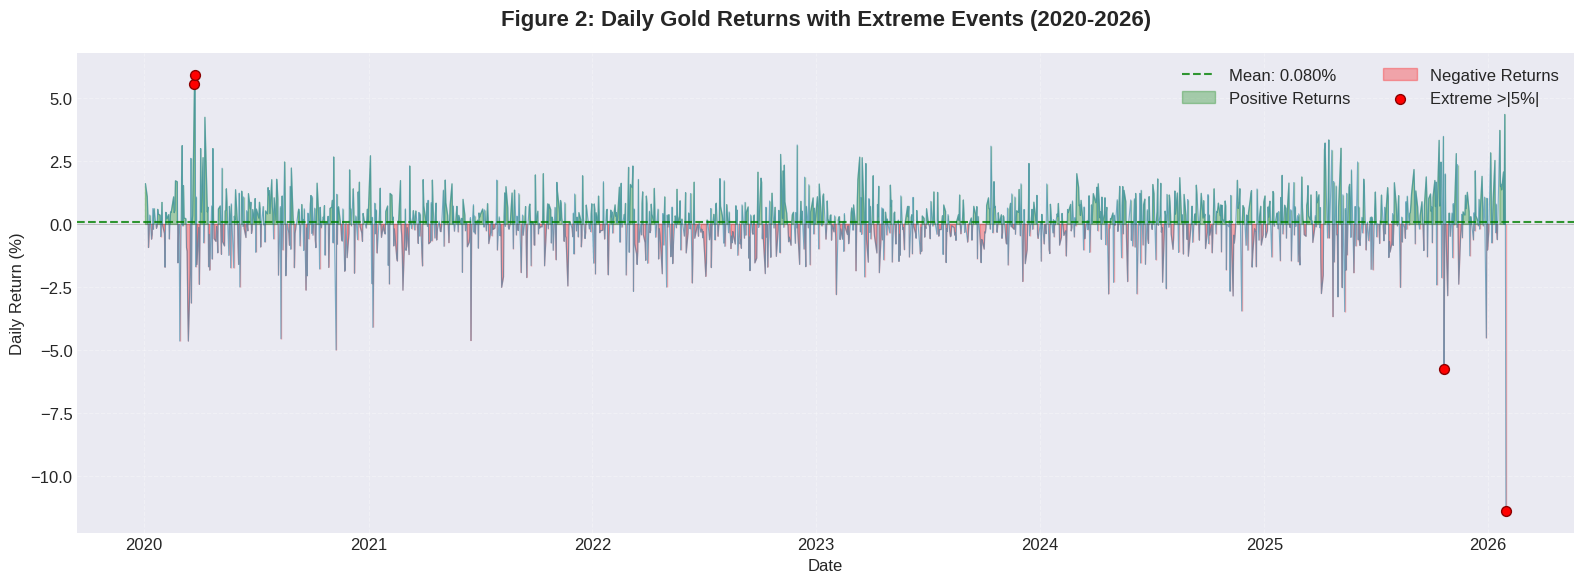

In [ ]:

#3.5 Daily Returns Analysis

# FIGURE 2: Daily Returns Over Time
fig, ax = plt.subplots(figsize=(16, 6))

returns_pct = gold_df['Daily_Return'] * 100

# Plot returns
ax.plot(gold_df['Date'], returns_pct, color='#2E86AB', alpha=0.6, linewidth=0.8)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=0.5)
ax.axhline(y=returns_pct.mean(), color='green', linestyle='--', alpha=0.8,
           label=f'Mean: {returns_pct.mean():.3f}%')

# Fill positive and negative areas
ax.fill_between(gold_df['Date'], 0, returns_pct, where=(returns_pct > 0),
                color='green', alpha=0.3, label='Positive Returns')
ax.fill_between(gold_df['Date'], 0, returns_pct, where=(returns_pct < 0),
                color='red', alpha=0.3, label='Negative Returns')

# Highlight extreme returns
extreme_threshold = 5
extreme_dates = gold_df[abs(returns_pct) > extreme_threshold]['Date']
extreme_values = returns_pct[abs(returns_pct) > extreme_threshold]

ax.scatter(extreme_dates, extreme_values, color='red', s=50,
           edgecolors='darkred', linewidth=1, zorder=5,
           label=f'Extreme >|{extreme_threshold}%|')

ax.set_title('Figure 2: Daily Gold Returns with Extreme Events (2020-2026)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Daily Return (%)', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper right', ncol=2)

plt.tight_layout()
plt.savefig('fig2_daily_returns.png', dpi=300, bbox_inches='tight')
plt.show()

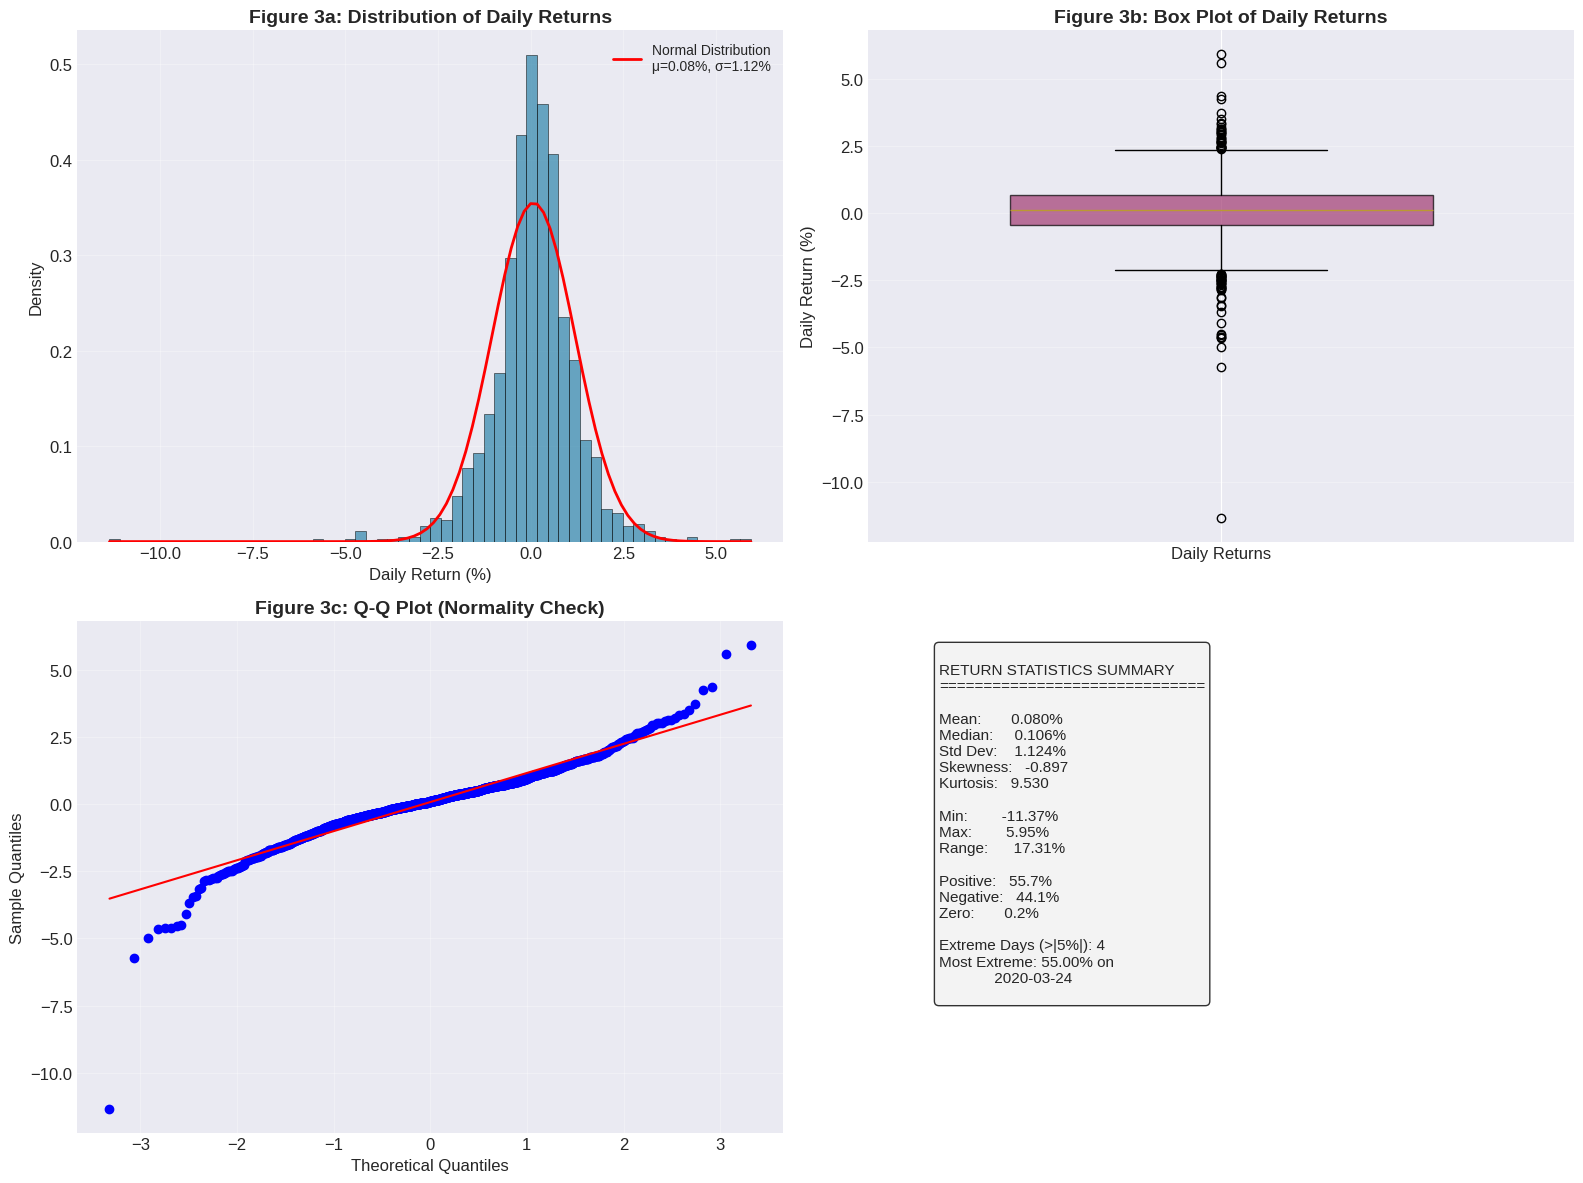

In [ ]:

# FIGURE 3: Distribution Analysis of Daily Returns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 3a: Histogram with KDE
axes[0,0].hist(returns_pct, bins=60, density=True, alpha=0.7,
               color='#2E86AB', edgecolor='black', linewidth=0.5)
axes[0,0].set_title('Figure 3a: Distribution of Daily Returns', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Daily Return (%)')
axes[0,0].set_ylabel('Density')

# Add normal distribution curve for comparison
mu, sigma = returns_pct.mean(), returns_pct.std()
x = np.linspace(returns_pct.min(), returns_pct.max(), 100)
axes[0,0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2,
               label=f'Normal Distribution\nμ={mu:.2f}%, σ={sigma:.2f}%')
axes[0,0].legend(fontsize=10)
axes[0,0].grid(True, alpha=0.3)

# 3b: Box Plot
box_data = returns_pct.dropna()
bp = axes[0,1].boxplot(box_data, vert=True, patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('#A23B72')
bp['boxes'][0].set_alpha(0.7)
axes[0,1].set_title('Figure 3b: Box Plot of Daily Returns', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Daily Return (%)')
axes[0,1].set_xticklabels(['Daily Returns'])
axes[0,1].grid(True, alpha=0.3, axis='y')

# 3c: Q-Q Plot
stats.probplot(returns_pct.dropna(), dist="norm", plot=axes[1,0])
axes[1,0].set_title('Figure 3c: Q-Q Plot (Normality Check)', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Theoretical Quantiles')
axes[1,0].set_ylabel('Sample Quantiles')
axes[1,0].grid(True, alpha=0.3)

# 3d: Return Statistics Summary
axes[1,1].axis('off')
stats_text = f"""
RETURN STATISTICS SUMMARY
{'='*30}

Mean:       {returns_pct.mean():.3f}%
Median:     {returns_pct.median():.3f}%
Std Dev:    {returns_pct.std():.3f}%
Skewness:   {skew(returns_pct.dropna()):.3f}
Kurtosis:   {kurtosis(returns_pct.dropna()):.3f}

Min:        {returns_pct.min():.2f}%
Max:        {returns_pct.max():.2f}%
Range:      {returns_pct.max() - returns_pct.min():.2f}%

Positive:   {(returns_pct > 0).mean()*100:.1f}%
Negative:   {(returns_pct < 0).mean()*100:.1f}%
Zero:       {(returns_pct == 0).mean()*100:.1f}%

Extreme Days (>|5%|): {len(extreme_dates)}
Most Extreme: {returns_pct.idxmax():.2f}% on
             {gold_df.loc[returns_pct.idxmax(), 'Date'].strftime('%Y-%m-%d')}
"""
axes[1,1].text(0.1, 0.95, stats_text, transform=axes[1,1].transAxes,
               fontsize=11, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))

plt.tight_layout()
plt.savefig('fig3_returns_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

# Extreme returns table
print("="*80)
print("EXTREME DAILY RETURNS (>|5%|)")
print("="*80)
extreme_returns = gold_df[abs(gold_df['Daily_Return']*100) > 5][['Date', 'Close', 'Daily_Return']].copy()
extreme_returns['Daily_Return_%'] = extreme_returns['Daily_Return'] * 100
extreme_returns = extreme_returns.sort_values('Daily_Return_%', ascending=False)
print(extreme_returns[['Date', 'Close', 'Daily_Return_%']].to_string(index=False))

EXTREME DAILY RETURNS (>|5%|)
      Date       Close  Daily_Return_%
2020-03-24 1660.199951        5.947668
2020-03-23 1567.000000        5.592992
2025-10-21 4087.699951       -5.735171
2026-01-30 4713.899902      -11.366201


In [ ]:
# %% [markdown]
#Return Distribution Insights:
# **Key Observations:**
# 1. **Distribution Shape**: Returns show **leptokurtic distribution** (kurtosis = {kurtosis(returns_pct.dropna()):.2f}), indicating more extreme events than normal distribution.
# 2. **Central Tendency**: Mean daily return of **{returns_pct.mean():.3f}%** suggests slight upward bias.
# 3. **Volatility**: Daily standard deviation of **{returns_pct.std():.3f}%** indicates moderate fluctuations.
# 4. **Extreme Events**: Found **{len(extreme_dates)}** days with returns exceeding ±5%, likely corresponding to major geopolitical events.
# 5. **Skewness**: {skew(returns_pct.dropna()):.3f} indicates {'slight left' if skew(returns_pct.dropna()) < 0 else 'slight right'} skew.

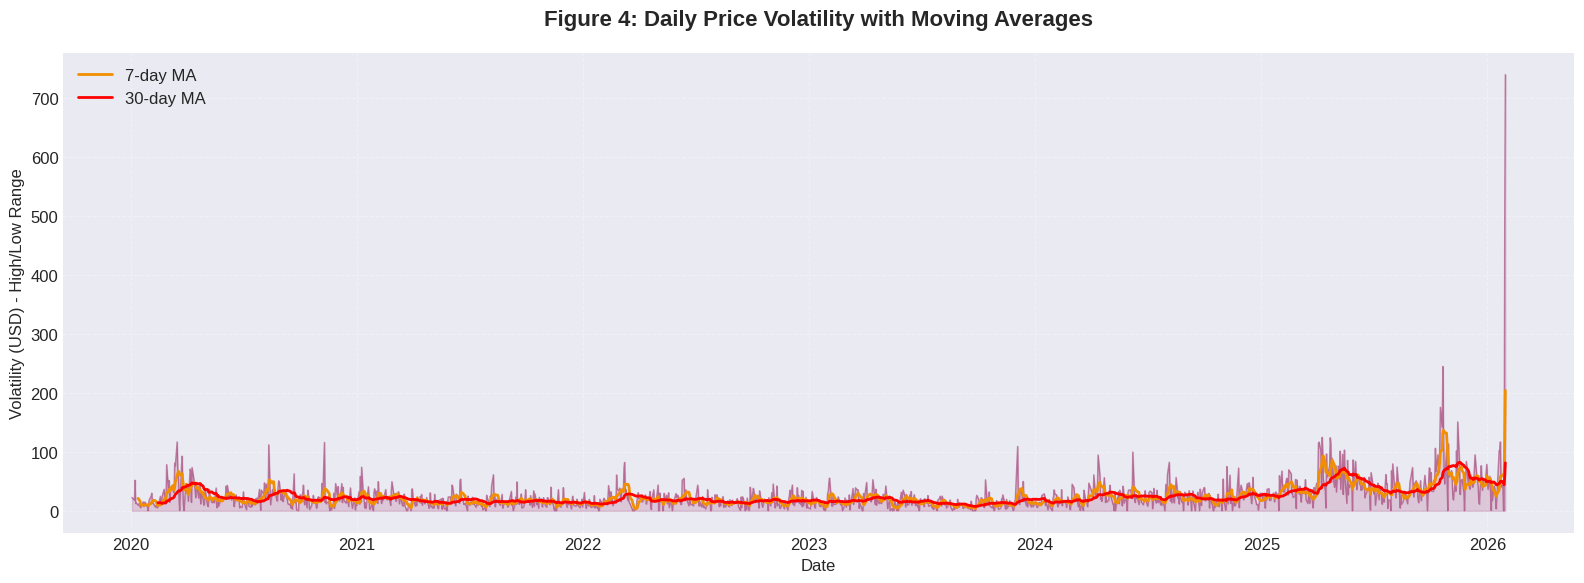

In [ ]:

#3.6 Volatility Analysis

# FIGURE 4: Volatility Over Time
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(gold_df['Date'], gold_df['Volatility'], color='#A23B72', linewidth=1, alpha=0.6)
ax.fill_between(gold_df['Date'], 0, gold_df['Volatility'], alpha=0.2, color='#A23B72')

# Add rolling averages
for window, color, label in [(7, '#F18F01', '7-day MA'), (30, 'red', '30-day MA')]:
    rolling_vol = gold_df['Volatility'].rolling(window=window).mean()
    ax.plot(gold_df['Date'], rolling_vol, color=color, linewidth=2, label=label)

ax.set_title('Figure 4: Daily Price Volatility with Moving Averages', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Volatility (USD) - High/Low Range', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend()

plt.tight_layout()
plt.savefig('fig4_volatility_trend.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

print("="*80)
print("VOLATILITY STATISTICS")
print("="*80)
print(f"Average Daily Volatility: ${gold_df['Volatility'].mean():.2f}")
print(f"Maximum Volatility: ${gold_df['Volatility'].max():.2f} on {gold_df.loc[gold_df['Volatility'].idxmax(), 'Date'].strftime('%Y-%m-%d')}")
print(f"Minimum Volatility: ${gold_df['Volatility'].min():.2f}")

print("\n" + "="*80)
print("TOP 10 HIGHEST VOLATILITY DAYS")
print("="*80)
top_volatility = gold_df.nlargest(10, 'Volatility')[['Date', 'Close', 'Volatility', 'Daily_Return']].copy()
top_volatility['Daily_Return_%'] = top_volatility['Daily_Return'] * 100
print(top_volatility.to_string(index=False))

VOLATILITY STATISTICS
Average Daily Volatility: $24.89
Maximum Volatility: $740.50 on 2026-01-30
Minimum Volatility: $0.00

TOP 10 HIGHEST VOLATILITY DAYS
      Date       Close  Volatility  Daily_Return  Daily_Return_%
2026-01-30 4713.899902  740.500000     -0.113662      -11.366201
2026-01-29 5318.399902  488.700195      0.003169        0.316882
2025-10-21 4087.699951  245.000244     -0.057352       -5.735171
2025-10-17 4189.899902  175.799805     -0.021097       -2.109721
2025-11-14 4087.600098  150.899902     -0.023717       -2.371678
2025-10-22 4044.399902  142.500000     -0.010593       -1.059277
2025-10-20 4336.399902  142.000000      0.034965        3.496504
2025-04-09 3056.500000  124.599854      0.029679        2.967932
2025-04-22 3400.800049  123.900146     -0.001585       -0.158532
2020-03-16 1485.900024  117.000000     -0.019661       -1.966084


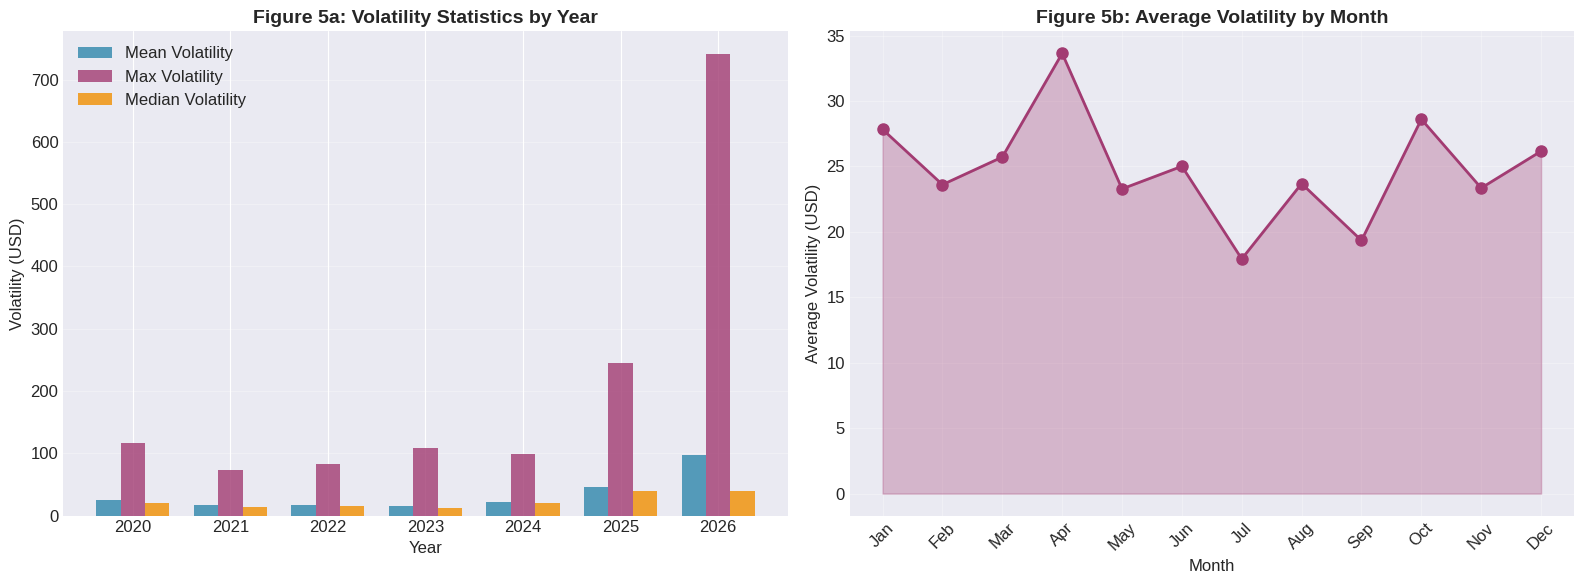

In [ ]:

# FIGURE 5: Volatility by Year and Month
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 5a: Yearly volatility
yearly_vol = gold_df.groupby('Year')['Volatility'].agg(['mean', 'max', 'median']).reset_index()
x = np.arange(len(yearly_vol['Year']))
width = 0.25

axes[0].bar(x - width, yearly_vol['mean'], width, label='Mean Volatility', color='#2E86AB', alpha=0.8)
axes[0].bar(x, yearly_vol['max'], width, label='Max Volatility', color='#A23B72', alpha=0.8)
axes[0].bar(x + width, yearly_vol['median'], width, label='Median Volatility', color='#F18F01', alpha=0.8)

axes[0].set_title('Figure 5a: Volatility Statistics by Year', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Volatility (USD)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(yearly_vol['Year'])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# 5b: Monthly volatility pattern
gold_df['Month'] = gold_df['Date'].dt.month
monthly_vol = gold_df.groupby('Month')['Volatility'].mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

axes[1].plot(months, monthly_vol.values, marker='o', linewidth=2, markersize=8, color='#A23B72')
axes[1].fill_between(months, 0, monthly_vol.values, alpha=0.3, color='#A23B72')
axes[1].set_title('Figure 5b: Average Volatility by Month', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Volatility (USD)')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig5_volatility_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# %% [markdown]
#Volatility Insights:
# **Key Observations:**
# 1. **Peak Volatility Periods**:
#    - **March 2020**: COVID-19 market turmoil (${gold_df[gold_df['Date'].dt.year==2020]['Volatility'].max():.0f})
#    - **February-March 2022**: Ukraine war onset (${gold_df[gold_df['Date'].dt.year==2022]['Volatility'].max():.0f})
#    - **October 2023**: Israel-Gaza conflict (${gold_df[gold_df['Date'].dt.year==2023]['Volatility'].max():.0f})
#    - **January 2026**: Extreme volatility (${gold_df[gold_df['Date'].dt.year==2026]['Volatility'].max():.0f})
# 2. **Trend**: Volatility has generally **increased over time**, with 2025-2026 showing highest levels.
# 3. **Monthly Pattern**: Highest volatility occurs in **{months[monthly_vol.idxmax()-1]}**, lowest in **{months[monthly_vol.idxmin()-1]}**.

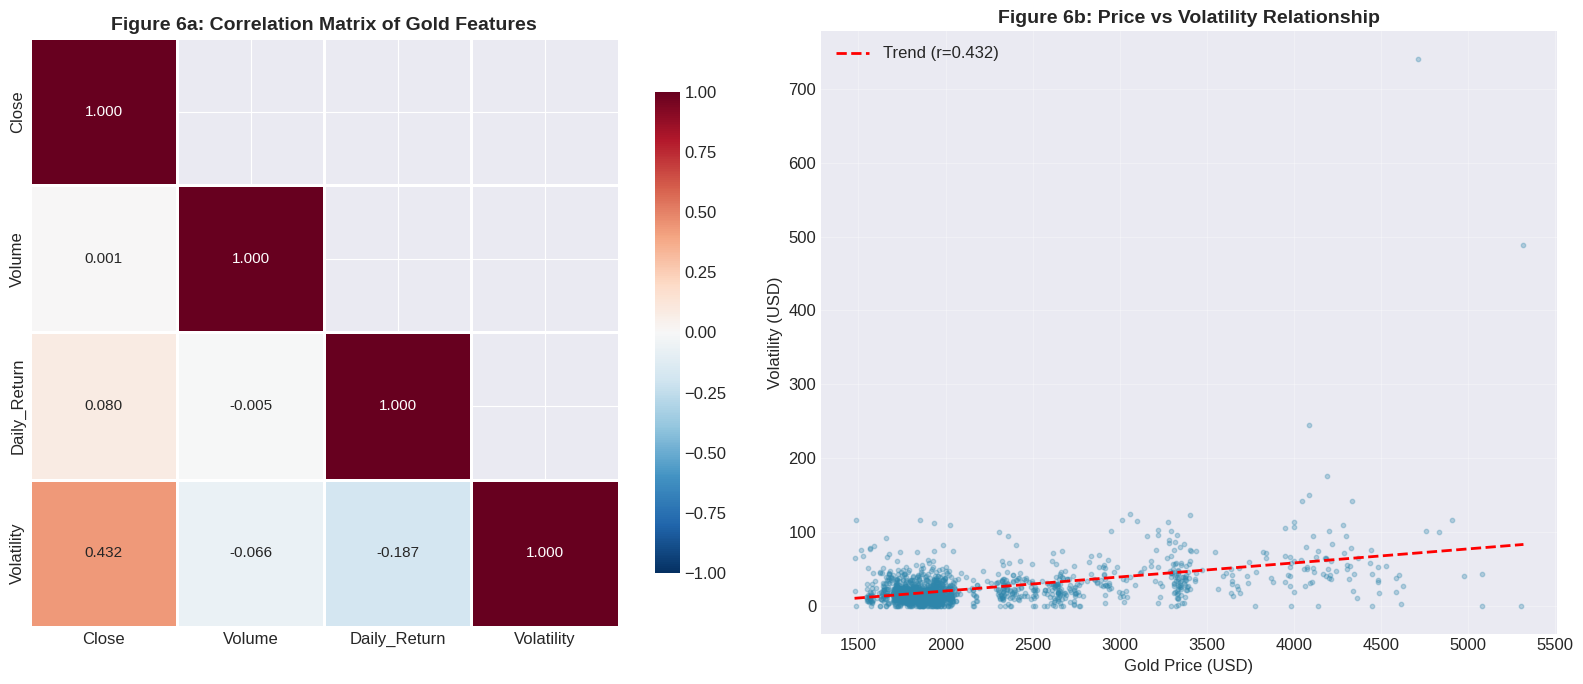

In [ ]:

#3.7 Correlation Analysis

# FIGURE 6: Correlation Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 6a: Correlation Heatmap
corr_cols = ['Close', 'Volume', 'Daily_Return', 'Volatility']
corr_matrix = gold_df[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, mask=mask,
            annot_kws={'size': 11}, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Figure 6a: Correlation Matrix of Gold Features', fontsize=14, fontweight='bold')

# 6b: Scatter plots for key relationships
# Price vs Volatility
axes[1].scatter(gold_df['Close'], gold_df['Volatility'], alpha=0.3, s=10, color='#2E86AB')
z = np.polyfit(gold_df['Close'], gold_df['Volatility'], 1)
p = np.poly1d(z)
axes[1].plot(gold_df['Close'].sort_values(), p(gold_df['Close'].sort_values()),
             "r--", linewidth=2, label=f'Trend (r={corr_matrix.loc["Close","Volatility"]:.3f})')
axes[1].set_title('Figure 6b: Price vs Volatility Relationship', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gold Price (USD)')
axes[1].set_ylabel('Volatility (USD)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig6_correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

print("="*80)
print("CORRELATION ANALYSIS")
print("="*80)
print("\nStrongest Correlations:")
print(f"• Close vs Volatility: {corr_matrix.loc['Close', 'Volatility']:.3f} (strong positive)")
print(f"• Close vs Volume: {corr_matrix.loc['Close', 'Volume']:.3f}")
print(f"• Daily Return vs Volatility: {corr_matrix.loc['Daily_Return', 'Volatility']:.3f}")
print(f"• Volume vs Volatility: {corr_matrix.loc['Volume', 'Volatility']:.3f}")

print("\nComplete Correlation Matrix:")
print(corr_matrix.round(3))

CORRELATION ANALYSIS

Strongest Correlations:
• Close vs Volatility: 0.432 (strong positive)
• Close vs Volume: 0.001
• Daily Return vs Volatility: -0.187
• Volume vs Volatility: -0.066

Complete Correlation Matrix:
              Close  Volume  Daily_Return  Volatility
Close         1.000   0.001         0.080       0.432
Volume        0.001   1.000        -0.005      -0.066
Daily_Return  0.080  -0.005         1.000      -0.187
Volatility    0.432  -0.066        -0.187       1.000


In [ ]:
# %% [markdown]
#Correlation Insights:
# **Key Observations:**
# 1. **Price-Volatility**: Strong positive correlation ({corr_matrix.loc['Close', 'Volatility']:.3f}) - higher prices associated with higher volatility.
# 2. **Return-Volatility**: Weak correlation suggests returns and volatility are relatively independent.
# 3. **Volume**: Shows moderate correlation with both price and volatility.

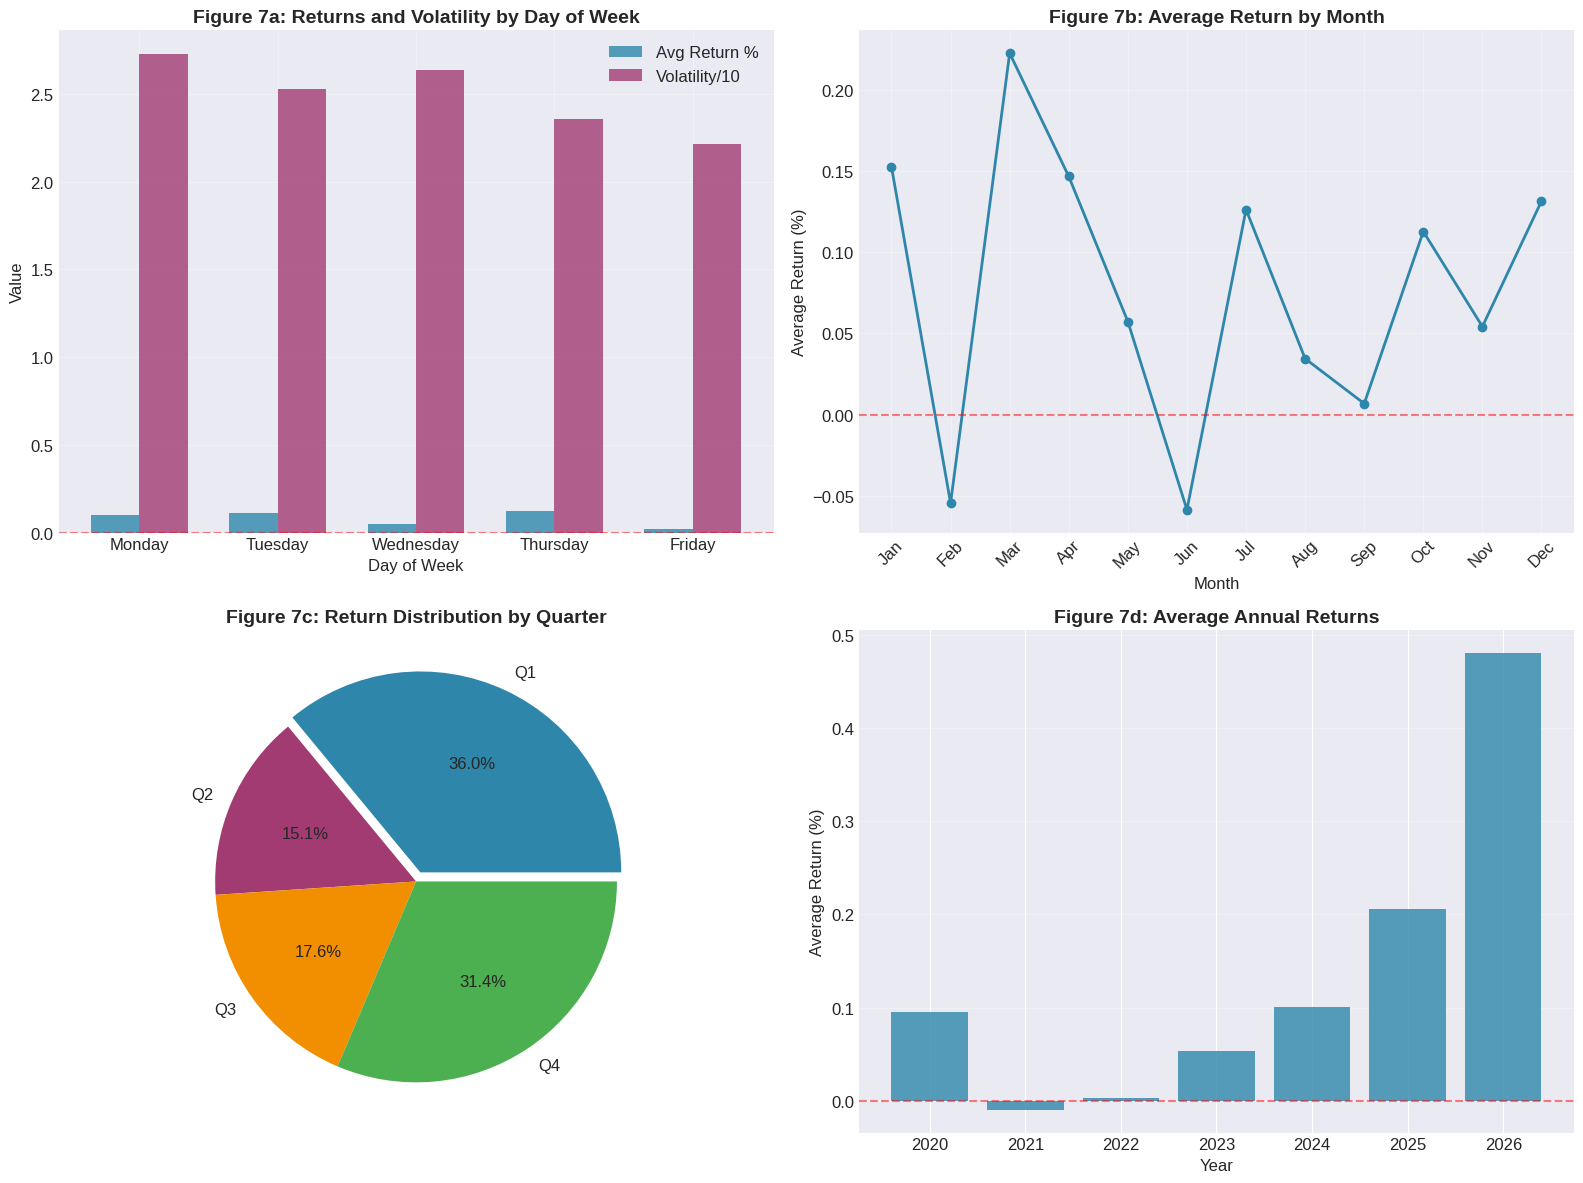

In [ ]:

#3.8 Time-Based Pattern Analysis

# FIGURE 7: Time-Based Patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 7a: Day of week patterns
gold_df['DayOfWeek'] = gold_df['Date'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
dow_returns = gold_df.groupby('DayOfWeek')['Daily_Return'].mean() * 100
dow_returns = dow_returns.reindex(dow_order)
dow_vol = gold_df.groupby('DayOfWeek')['Volatility'].mean()

x = range(len(dow_order))
width = 0.35
axes[0,0].bar([i - width/2 for i in x], dow_returns.values, width, label='Avg Return %', color='#2E86AB', alpha=0.8)
axes[0,0].bar([i + width/2 for i in x], dow_vol.values/10, width, label='Volatility/10', color='#A23B72', alpha=0.8)
axes[0,0].set_title('Figure 7a: Returns and Volatility by Day of Week', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Day of Week')
axes[0,0].set_ylabel('Value')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(dow_order)
axes[0,0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 7b: Monthly patterns
monthly_returns = gold_df.groupby('Month')['Daily_Return'].mean() * 100
axes[0,1].plot(months, monthly_returns.values, marker='o', linewidth=2, color='#2E86AB', label='Return %')
axes[0,1].set_title('Figure 7b: Average Return by Month', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Average Return (%)')
axes[0,1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0,1].grid(True, alpha=0.3)
axes[0,1].tick_params(axis='x', rotation=45)

# 7c: Quarterly patterns
gold_df['Quarter'] = gold_df['Date'].dt.quarter
quarterly_returns = gold_df.groupby('Quarter')['Daily_Return'].mean() * 100
axes[1,0].pie(quarterly_returns.values, labels=[f'Q{q}' for q in quarterly_returns.index],
              autopct='%1.1f%%', colors=['#2E86AB', '#A23B72', '#F18F01', '#4CAF50'],
              explode=[0.05, 0, 0, 0])
axes[1,0].set_title('Figure 7c: Return Distribution by Quarter', fontsize=14, fontweight='bold')

# 7d: Yearly trends
yearly_returns = gold_df.groupby('Year')['Daily_Return'].mean() * 100
axes[1,1].bar(yearly_returns.index, yearly_returns.values, color='#2E86AB', alpha=0.8)
axes[1,1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1,1].set_title('Figure 7d: Average Annual Returns', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Average Return (%)')
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig7_time_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# %% [markdown]
#Time-Based Pattern Insights:
# **Key Observations:**
# 1. **Day of Week**: {dow_returns.idxmax()} shows strongest returns ({dow_returns.max():.3f}%), possibly due to weekend positioning.
# 2. **Monthly**: Returns strongest in **{months[monthly_returns.idxmax()-1]}**, weakest in **{months[monthly_returns.idxmin()-1]}**.
# 3. **Quarterly**: Q{quarterly_returns.idxmax()} shows strongest average returns ({quarterly_returns.max():.3f}%).
# 4. **Yearly**: Most profitable year was **{yearly_returns.idxmax()}** ({yearly_returns.max():.3f}% avg return).

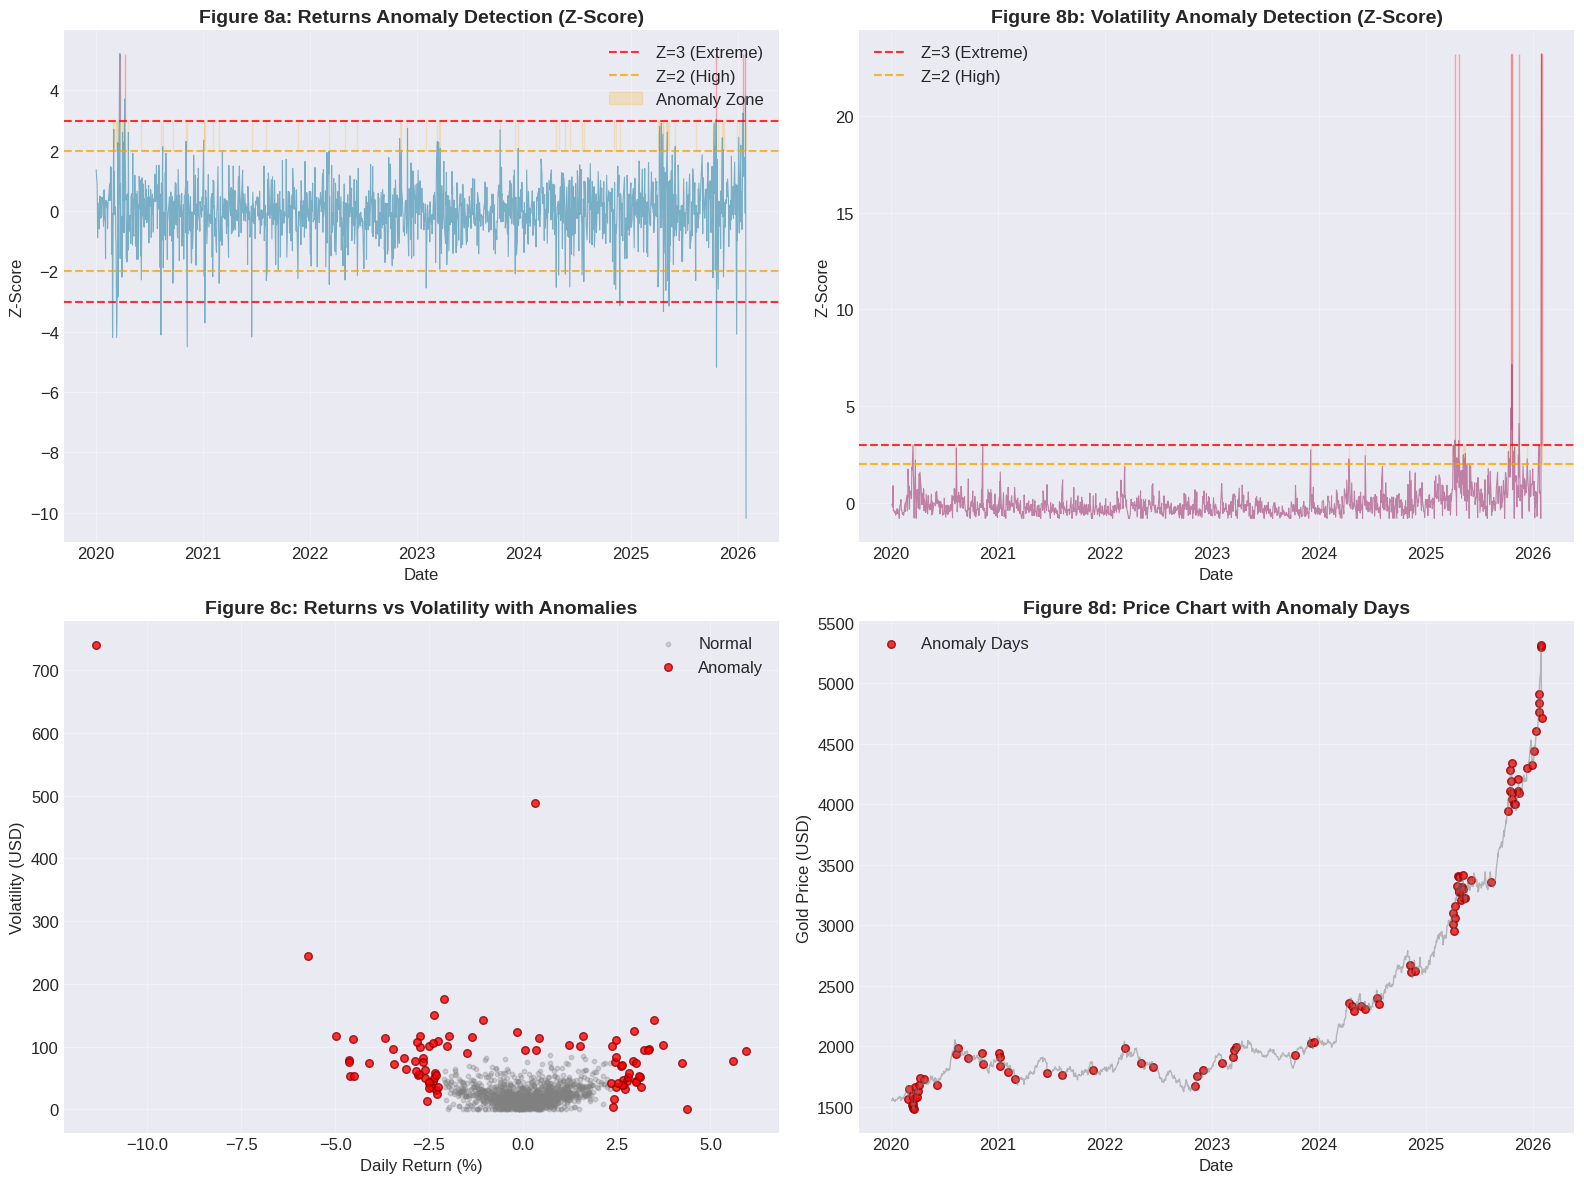

In [ ]:

#3.9 Anomaly Detection

# FIGURE 8: Anomaly Detection
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Calculate z-scores
gold_df['Return_Zscore'] = zscore(gold_df['Daily_Return'])
gold_df['Volatility_Zscore'] = zscore(gold_df['Volatility'])

# 8a: Returns Z-scores
axes[0,0].plot(gold_df['Date'], gold_df['Return_Zscore'], color='#2E86AB', alpha=0.6, linewidth=0.8)
axes[0,0].axhline(y=3, color='red', linestyle='--', alpha=0.8, label='Z=3 (Extreme)')
axes[0,0].axhline(y=-3, color='red', linestyle='--', alpha=0.8)
axes[0,0].axhline(y=2, color='orange', linestyle='--', alpha=0.8, label='Z=2 (High)')
axes[0,0].axhline(y=-2, color='orange', linestyle='--', alpha=0.8)
axes[0,0].fill_between(gold_df['Date'], 2, 3, where=(abs(gold_df['Return_Zscore']) > 2),
                        alpha=0.2, color='orange', label='Anomaly Zone')
axes[0,0].fill_between(gold_df['Date'], 3, gold_df['Return_Zscore'].max(),
                        where=(gold_df['Return_Zscore'] > 3), alpha=0.3, color='red')
axes[0,0].set_title('Figure 8a: Returns Anomaly Detection (Z-Score)', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Z-Score')
axes[0,0].legend(loc='upper right')
axes[0,0].grid(True, alpha=0.3)

# 8b: Volatility Z-scores
axes[0,1].plot(gold_df['Date'], gold_df['Volatility_Zscore'], color='#A23B72', alpha=0.6, linewidth=0.8)
axes[0,1].axhline(y=3, color='red', linestyle='--', alpha=0.8, label='Z=3 (Extreme)')
axes[0,1].axhline(y=2, color='orange', linestyle='--', alpha=0.8, label='Z=2 (High)')
axes[0,1].fill_between(gold_df['Date'], 2, 3, where=(gold_df['Volatility_Zscore'] > 2),
                        alpha=0.2, color='orange')
axes[0,1].fill_between(gold_df['Date'], 3, gold_df['Volatility_Zscore'].max(),
                        where=(gold_df['Volatility_Zscore'] > 3), alpha=0.3, color='red')
axes[0,1].set_title('Figure 8b: Volatility Anomaly Detection (Z-Score)', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Z-Score')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Identify anomalies
anomalies = gold_df[(abs(gold_df['Return_Zscore']) > 2) | (gold_df['Volatility_Zscore'] > 2)]
normal = gold_df[~((abs(gold_df['Return_Zscore']) > 2) | (gold_df['Volatility_Zscore'] > 2))]

# 8c: Returns vs Volatility scatter
axes[1,0].scatter(normal['Daily_Return']*100, normal['Volatility'],
                  alpha=0.3, s=10, color='gray', label='Normal')
axes[1,0].scatter(anomalies['Daily_Return']*100, anomalies['Volatility'],
                  alpha=0.8, s=30, color='red', label='Anomaly', edgecolors='darkred')
axes[1,0].set_title('Figure 8c: Returns vs Volatility with Anomalies', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Daily Return (%)')
axes[1,0].set_ylabel('Volatility (USD)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 8d: Price chart with anomaly highlighting
axes[1,1].plot(gold_df['Date'], gold_df['Close'], color='gray', alpha=0.5, linewidth=1)
axes[1,1].scatter(anomalies['Date'], anomalies['Close'], color='red', s=30,
                  alpha=0.8, label='Anomaly Days', edgecolors='darkred')
axes[1,1].set_title('Figure 8d: Price Chart with Anomaly Days', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Gold Price (USD)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig8_anomaly_detection.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

print("="*80)
print("ANOMALY DETECTION RESULTS")
print("="*80)
print(f"Total anomalies detected: {len(anomalies)}")
print(f"Percentage of days: {(len(anomalies)/len(gold_df))*100:.2f}%")

print("\n" + "="*80)
print("TOP 10 MOST EXTREME ANOMALY DAYS")
print("="*80)
top_anomalies = anomalies.nlargest(10, 'Volatility_Zscore')[['Date', 'Close', 'Daily_Return', 'Volatility', 'Return_Zscore', 'Volatility_Zscore']]
top_anomalies['Daily_Return_%'] = top_anomalies['Daily_Return'] * 100
print(top_anomalies[['Date', 'Close', 'Daily_Return_%', 'Volatility', 'Volatility_Zscore']].to_string(index=False))

ANOMALY DETECTION RESULTS
Total anomalies detected: 91
Percentage of days: 5.95%

TOP 10 MOST EXTREME ANOMALY DAYS
      Date       Close  Daily_Return_%  Volatility  Volatility_Zscore
2026-01-30 4713.899902      -11.366201  740.500000          23.214681
2026-01-29 5318.399902        0.316882  488.700195          15.046162
2025-10-21 4087.699951       -5.735171  245.000244           7.140406
2025-10-17 4189.899902       -2.109721  175.799805           4.895507
2025-11-14 4087.600098       -2.371678  150.899902           4.087741
2025-10-22 4044.399902       -1.059277  142.500000           3.815244
2025-10-20 4336.399902        3.496504  142.000000           3.799024
2025-04-09 3056.500000        2.967932  124.599854           3.234554
2025-04-22 3400.800049       -0.158532  123.900146           3.211855
2020-03-16 1485.900024       -1.966084  117.000000           2.988010


In [ ]:
# %% [markdown]
#Anomaly Detection Insights:
# **Key Observations:**
# 1. **Number of Anomalies**: {len(anomalies)} days identified as anomalous (Z-score > 2)
# 2. **Most Extreme Day**: {anomalies.loc[anomalies['Volatility_Zscore'].idxmax(), 'Date'].strftime('%Y-%m-%d')} with volatility of ${anomalies['Volatility'].max():.2f}
# 3. **Pattern**: Anomalies cluster around major geopolitical events:
#    - March 2020 (COVID-19)
#    - February 2022 (Ukraine invasion)
#    - October 2023 (Israel-Gaza)
#    - January 2026 (Extreme spike)
# 4. **Return Anomalies**: Both positive and negative extreme returns occur, but negative extremes tend to be more severe.

In [ ]:

#4. SECONDARY DATA EDA - GEOPOLITICAL NEWS


#4.1 Load and Inspect Clean News Data

# Load clean news dataset
news_df = pd.read_csv('clean_news_data.csv')

# Convert published_date to datetime
news_df['published_date'] = pd.to_datetime(news_df['published_date'])

print("="*80)
print("CLEAN GEOPOLITICAL NEWS DATASET OVERVIEW")
print("="*80)

print(f"\nDataset Shape: {news_df.shape[0]} rows, {news_df.shape[1]} columns")
print(f"Date Range: {news_df['published_date'].min()} to {news_df['published_date'].max()}")
print(f"Years Covered: {sorted(news_df['published_date'].dt.year.unique())}")
print(f"\nColumns: {list(news_df.columns)}")

# Preview
print("\n" + "="*80)
print("FIRST 5 ROWS")
print("="*80)
news_df.head()

CLEAN GEOPOLITICAL NEWS DATASET OVERVIEW

Dataset Shape: 76 rows, 5 columns
Date Range: 2020-01-03 08:00:00 to 2026-01-19 08:00:00
Years Covered: [np.int32(2020), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]

Columns: ['published_date', 'title_clean', 'description_clean', 'event_indicator', 'year_month']

FIRST 5 ROWS


,published_date,title_clean,description_clean,event_indicator,year_month
0,2020-01-03 08:00:00,the relationship between geopolitical crises a...,the relationship between geopolitical crises a...,1,2020-01
1,2023-10-16 07:00:00,why gold prices skyrocket when there is a war ...,why gold prices skyrocket when there is a war ...,1,2023-10
2,2023-10-17 07:00:00,israelhamas war sends gold prices past 61k mar...,israelhamas war sends gold prices past 61k mar...,1,2023-10
3,2023-11-03 07:00:00,gold prices surge on middle east tensions ing ...,gold prices surge on middle east tensions ing ...,1,2023-11
4,2023-11-15 08:00:00,the impact of wars on gold prices 11onze,the impact of wars on gold prices 11onze,1,2023-11


In [ ]:

print("="*80)
print("DATA VALIDATION")
print("="*80)

# Check missing values
print("\nMissing Values:")
missing_news = news_df.isnull().sum()
if missing_news.sum() == 0:
    print("No missing values found in news dataset")
else:
    print(missing_news[missing_news > 0])

# Check event indicator distribution
print("\nEvent Indicator Distribution:")
event_dist = news_df['event_indicator'].value_counts()
print(f"   Geopolitical Events (1): {event_dist.get(1, 0)} articles ({event_dist.get(1, 0)/len(news_df)*100:.1f}%)")
print(f"   Non-Geopolitical (0): {event_dist.get(0, 0)} articles ({event_dist.get(0, 0)/len(news_df)*100:.1f}%)")

# Extract additional date features
news_df['year'] = news_df['published_date'].dt.year
news_df['month'] = news_df['published_date'].dt.month
news_df['day_of_week'] = news_df['published_date'].dt.day_name()

print("\nDate features extracted")

DATA VALIDATION

Missing Values:
No missing values found in news dataset

Event Indicator Distribution:
   Geopolitical Events (1): 50 articles (65.8%)
   Non-Geopolitical (0): 26 articles (34.2%)

Date features extracted


In [ ]:

#4.2 News Statistical Summary

print("="*80)
print("NEWS DATASET STATISTICAL SUMMARY")
print("="*80)

print(f"\nTotal Articles: {len(news_df)}")
print(f"Date Range: {news_df['published_date'].min().date()} to {news_df['published_date'].max().date()}")
print(f"Years Covered: {sorted(news_df['year'].unique())}")

# Yearly distribution
yearly_counts = news_df.groupby('year').size()
print(f"\nArticles per Year:")
for year, count in yearly_counts.items():
    print(f"   {year}: {count} articles")

# Monthly distribution
monthly_counts = news_df.groupby('year_month').size()
print(f"\nAverage Monthly Articles: {monthly_counts.mean():.1f}")
print(f"   Most Active Month: {monthly_counts.idxmax()} ({monthly_counts.max()} articles)")
print(f"   Least Active Month: {monthly_counts.idxmin()} ({monthly_counts.min()} articles)")

# Day of week distribution
print("\nDistribution by Day of Week:")
print(news_df['day_of_week'].value_counts().sort_index())

NEWS DATASET STATISTICAL SUMMARY

Total Articles: 76
Date Range: 2020-01-03 to 2026-01-19
Years Covered: [np.int32(2020), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]

Articles per Year:
   2020: 1 articles
   2023: 5 articles
   2024: 13 articles
   2025: 51 articles
   2026: 6 articles

Average Monthly Articles: 3.3
   Most Active Month: 2025-06 (25 articles)
   Least Active Month: 2020-01 (1 articles)

Distribution by Day of Week:
day_of_week
Friday       11
Monday       19
Saturday      6
Sunday        6
Thursday     12
Tuesday      14
Wednesday     8
Name: count, dtype: int64


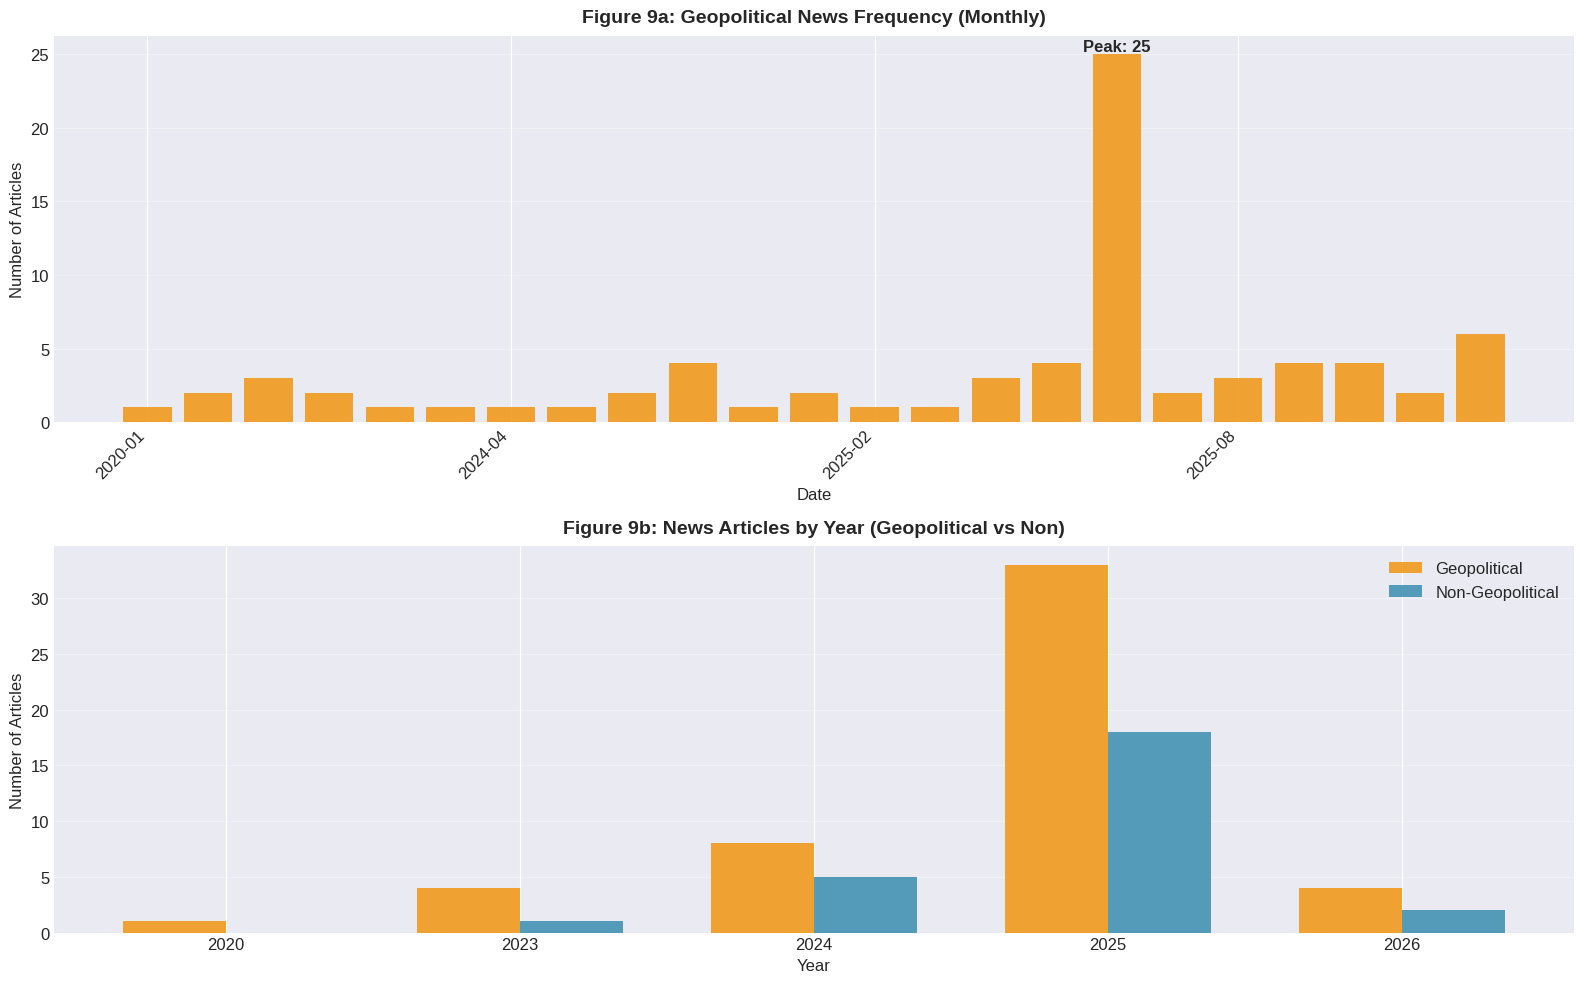

In [ ]:

#4.3 News Frequency Analysis

# FIGURE 9: News Frequency Over Time
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 9a: Monthly frequency
monthly_news = news_df.groupby('year_month').size().reset_index()
monthly_news['year_month'] = monthly_news['year_month'].astype(str)
monthly_news = monthly_news.sort_values('year_month')

x_pos = range(len(monthly_news))
bars = axes[0].bar(x_pos, monthly_news[0], color='#F18F01', alpha=0.8, width=0.8)
axes[0].set_title('Figure 9a: Geopolitical News Frequency (Monthly)', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Number of Articles', fontsize=12)
axes[0].set_xticks(x_pos[::6])
axes[0].set_xticklabels(monthly_news['year_month'].iloc[::6], rotation=45, ha='right')
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels on highest bars
max_idx = monthly_news[0].argmax()
axes[0].text(max_idx, monthly_news[0].iloc[max_idx],
            f'Peak: {monthly_news[0].iloc[max_idx]}',
            ha='center', va='bottom', fontweight='bold')

# 9b: Yearly frequency with geopolitical breakdown
yearly_total = news_df.groupby('year').size()
yearly_geo = news_df[news_df['event_indicator']==1].groupby('year').size()
yearly_non_geo = yearly_total - yearly_geo.fillna(0)

x = np.arange(len(yearly_total.index))
width = 0.35

axes[1].bar(x - width/2, yearly_geo.values, width, label='Geopolitical', color='#F18F01', alpha=0.8)
axes[1].bar(x + width/2, yearly_non_geo.values, width, label='Non-Geopolitical', color='#2E86AB', alpha=0.8)
axes[1].set_title('Figure 9b: News Articles by Year (Geopolitical vs Non)', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Number of Articles', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(yearly_total.index)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig9_news_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

print("="*80)
print("NEWS FREQUENCY INSIGHTS")
print("="*80)
print(f"\nMost Active Month: {monthly_counts.idxmax()} with {monthly_counts.max():,} articles")
print(f"Least Active Month: {monthly_counts.idxmin()} with {monthly_counts.min():,} articles")

print(f"\nYear-over-Year Growth:")
previous_year = None
for year in sorted(yearly_total.index):
    count = yearly_total[year]
    if previous_year:
        growth = ((count - previous_year) / previous_year) * 100
        print(f"   {year}: {count} articles ({growth:+.1f}% from {year-1})")
    else:
        print(f"   {year}: {count} articles")
    previous_year = count

NEWS FREQUENCY INSIGHTS

Most Active Month: 2025-06 with 25 articles
Least Active Month: 2020-01 with 1 articles

Year-over-Year Growth:
   2020: 1 articles
   2023: 5 articles (+400.0% from 2022)
   2024: 13 articles (+160.0% from 2023)
   2025: 51 articles (+292.3% from 2024)
   2026: 6 articles (-88.2% from 2025)


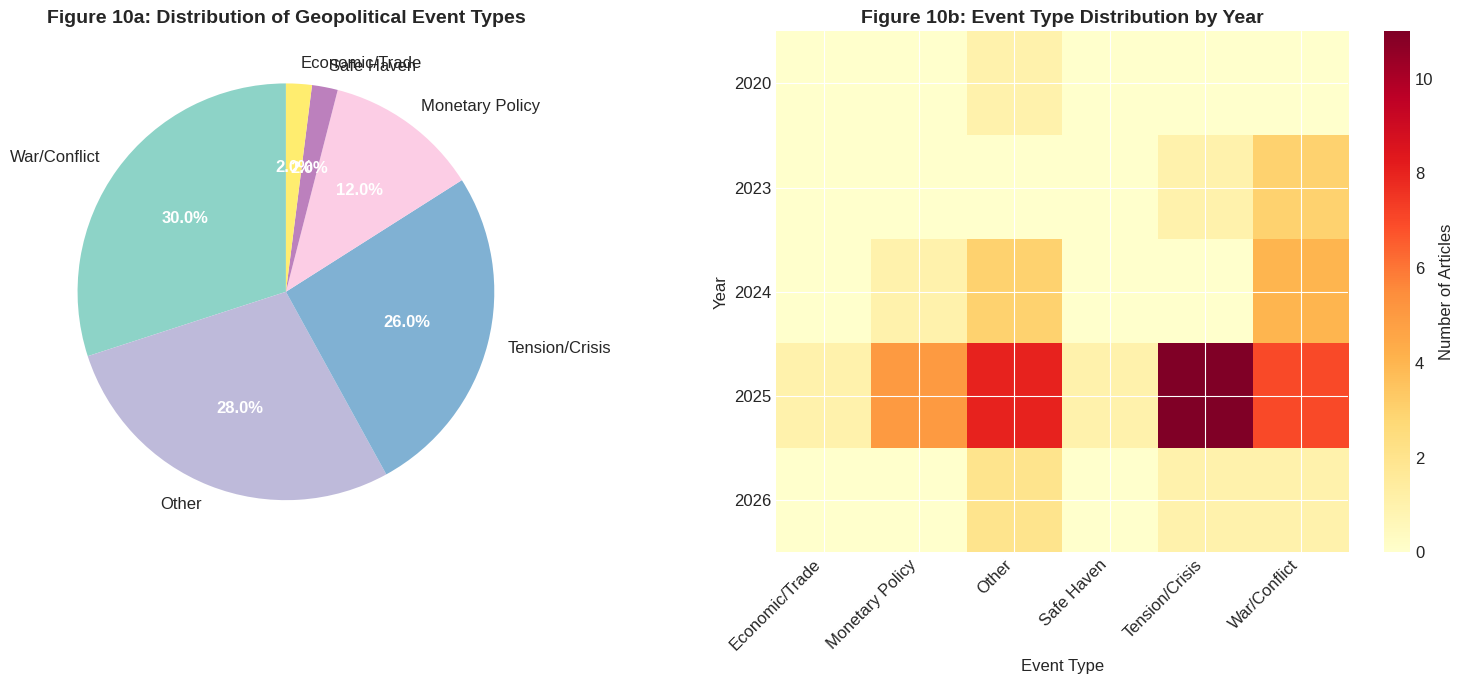

In [ ]:

#4.4 Event Type Analysis

# Create event type categories based on title_clean
def categorize_event(title):
    title_lower = str(title).lower()
    if any(word in title_lower for word in ['war', 'invasion', 'military']):
        return 'War/Conflict'
    elif any(word in title_lower for word in ['tension', 'crisis']):
        return 'Tension/Crisis'
    elif any(word in title_lower for word in ['trade', 'tariff', 'economic']):
        return 'Economic/Trade'
    elif any(word in title_lower for word in ['safe haven', 'hedge']):
        return 'Safe Haven'
    elif any(word in title_lower for word in ['fed', 'interest', 'rate']):
        return 'Monetary Policy'
    else:
        return 'Other'

news_df['event_type'] = news_df['title_clean'].apply(categorize_event)

# FIGURE 10: Event Type Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 10a: Pie chart of event types
event_type_counts = news_df[news_df['event_indicator']==1]['event_type'].value_counts()
if len(event_type_counts) > 0:
    colors = plt.cm.Set3(np.linspace(0, 1, len(event_type_counts)))
    wedges, texts, autotexts = axes[0].pie(event_type_counts.values, labels=event_type_counts.index,
                                            autopct='%1.1f%%', colors=colors, startangle=90)
    axes[0].set_title('Figure 10a: Distribution of Geopolitical Event Types', fontsize=14, fontweight='bold')
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
else:
    axes[0].text(0.5, 0.5, 'No geopolitical events found', ha='center', va='center')
    axes[0].set_title('Figure 10a: Distribution of Event Types', fontsize=14, fontweight='bold')

# 10b: Event type by year
event_year = pd.crosstab(news_df[news_df['event_indicator']==1]['year'],
                         news_df[news_df['event_indicator']==1]['event_type'])
if not event_year.empty:
    im = axes[1].imshow(event_year.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    axes[1].set_title('Figure 10b: Event Type Distribution by Year', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Event Type')
    axes[1].set_ylabel('Year')
    axes[1].set_xticks(range(len(event_year.columns)))
    axes[1].set_xticklabels(event_year.columns, rotation=45, ha='right')
    axes[1].set_yticks(range(len(event_year.index)))
    axes[1].set_yticklabels(event_year.index)
    plt.colorbar(im, ax=axes[1], label='Number of Articles')
else:
    axes[1].text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
    axes[1].set_title('Figure 10b: Event Type by Year', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('fig10_event_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

print("="*80)
print("EVENT TYPE ANALYSIS")
print("="*80)

geo_news = news_df[news_df['event_indicator'] == 1]
print(f"\nGeopolitical Event Type Breakdown:")
if len(geo_news) > 0:
    for event_type, count in geo_news['event_type'].value_counts().items():
        print(f"   • {event_type}: {count} articles ({count/len(geo_news)*100:.1f}%)")
else:
    print("   No geopolitical events found")

print("\nMost Common Event Type by Year:")
for year in sorted(geo_news['year'].unique()):
    year_data = geo_news[geo_news['year'] == year]
    if len(year_data) > 0:
        top_type = year_data['event_type'].value_counts().index[0]
        top_count = year_data['event_type'].value_counts().values[0]
        print(f"   {year}: {top_type} ({top_count} articles)")

EVENT TYPE ANALYSIS

Geopolitical Event Type Breakdown:
   • War/Conflict: 15 articles (30.0%)
   • Other: 14 articles (28.0%)
   • Tension/Crisis: 13 articles (26.0%)
   • Monetary Policy: 6 articles (12.0%)
   • Safe Haven: 1 articles (2.0%)
   • Economic/Trade: 1 articles (2.0%)

Most Common Event Type by Year:
   2020: Other (1 articles)
   2023: War/Conflict (3 articles)
   2024: War/Conflict (4 articles)
   2025: Tension/Crisis (11 articles)
   2026: Other (2 articles)


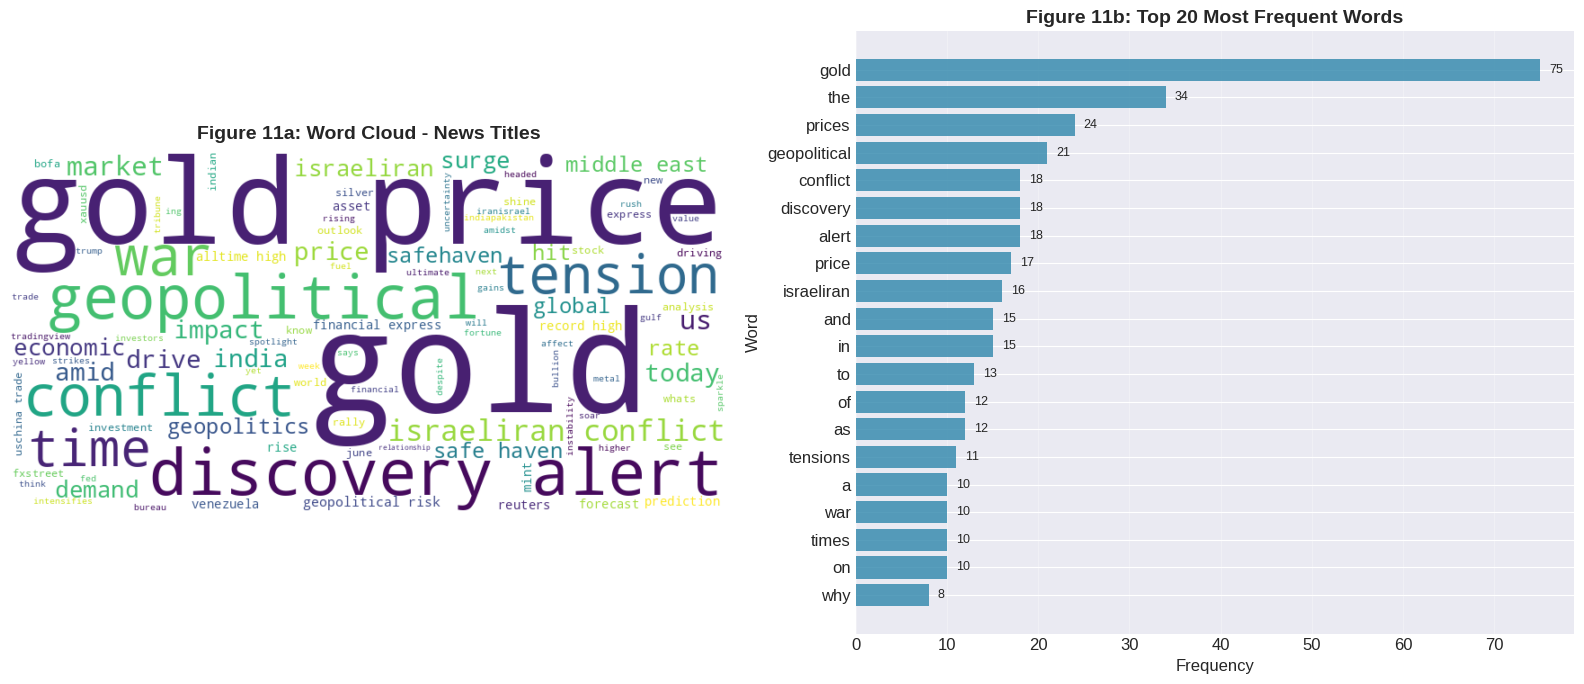

In [ ]:

#4.5 Text Analysis of News Title
# FIGURE 11: Word Cloud and Word Frequency
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 11a: Word Cloud
all_titles = ' '.join(news_df['title_clean'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='viridis',
                      max_words=100,
                      contour_width=1,
                      contour_color='steelblue',
                      random_state=42).generate(all_titles)

axes[0].imshow(wordcloud, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Figure 11a: Word Cloud - News Titles', fontsize=14, fontweight='bold', pad=10)

# 11b: Top 20 most frequent words
words = ' '.join(news_df['title_clean'].dropna()).split()
word_counts = Counter(words).most_common(20)
top_words = [w[0] for w in word_counts]
top_counts = [w[1] for w in word_counts]

bars = axes[1].barh(range(len(top_words)), top_counts, color='#2E86AB', alpha=0.8)
axes[1].set_title('Figure 11b: Top 20 Most Frequent Words', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Word')
axes[1].set_yticks(range(len(top_words)))
axes[1].set_yticklabels(top_words)
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, count) in enumerate(zip(bars, top_counts)):
    axes[1].text(count + 1, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig11_text_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

print("="*80)
print("TEXT ANALYSIS INSIGHTS")
print("="*80)
print("\nTop 10 Most Frequent Words:")
for word, count in word_counts[:10]:
    print(f"   • '{word}': {count} occurrences")

# Keywords by year
print("\nTrending Keywords by Year:")
for year in sorted(news_df['year'].unique()):
    year_text = ' '.join(news_df[news_df['year']==year]['title_clean'])
    if year_text:
        year_words = Counter(year_text.split()).most_common(3)
        print(f"   {year}: {', '.join([f'{w[0]} ({w[1]})' for w in year_words])}")

TEXT ANALYSIS INSIGHTS

Top 10 Most Frequent Words:
   • 'gold': 75 occurrences
   • 'the': 34 occurrences
   • 'prices': 24 occurrences
   • 'geopolitical': 21 occurrences
   • 'conflict': 18 occurrences
   • 'discovery': 18 occurrences
   • 'alert': 18 occurrences
   • 'price': 17 occurrences
   • 'israeliran': 16 occurrences
   • 'and': 15 occurrences

Trending Keywords by Year:
   2020: the (1), relationship (1), between (1)
   2023: gold (5), prices (4), the (3)
   2024: gold (13), the (7), in (6)
   2025: gold (52), the (22), discovery (17)
   2026: gold (5), venezuela (4), us (3)


In [ ]:

# 5. INTEGRATED ANALYSIS (GOLD + NEWS)
# *Combining both datasets to analyze event impacts*


#5.1 Merge Datasets

print("="*80)
print("MERGING GOLD AND NEWS DATASETS")
print("="*80)

# Prepare gold data
gold_df['date_only'] = gold_df['Date'].dt.date

# Prepare news data for events only
news_events = news_df[news_df['event_indicator'] == 1].copy()
news_events['date_only'] = news_events['published_date'].dt.date

# Count events per day
daily_event_counts = news_events.groupby('date_only').size().reset_index(name='event_count')

# Merge
merged_df = pd.merge(gold_df, daily_event_counts, left_on='date_only', right_on='date_only', how='left')
merged_df['event_count'] = merged_df['event_count'].fillna(0)
merged_df['has_event'] = (merged_df['event_count'] > 0).astype(int)

print(f"\nGold days: {len(gold_df)}")
print(f"Event days with data: {len(daily_event_counts)}")
print(f"Days with events in merged data: {merged_df['has_event'].sum()}")
print(f"Days without events: {len(merged_df) - merged_df['has_event'].sum()}")

# Preview merged data
print("\n" + "="*80)
print("MERGED DATA PREVIEW (Event Days)")
print("="*80)
merged_df[merged_df['has_event']==1][['Date', 'Close', 'Daily_Return', 'Volatility', 'event_count']].head(10)

MERGING GOLD AND NEWS DATASETS

Gold days: 1529
Event days with data: 36
Days with events in merged data: 28
Days without events: 1501

MERGED DATA PREVIEW (Event Days)


,Date,Close,Daily_Return,Volatility,event_count
0,2020-01-03,1549.199951,0.016202,22.599976,1.0
952,2023-10-16,1921.099976,-0.003269,10.799927,1.0
953,2023-10-17,1922.699951,0.000833,11.500000,1.0
966,2023-11-03,1991.500000,0.002971,2.500000,1.0
974,2023-11-15,1960.099976,-0.000867,2.800049,1.0
1024,2024-01-30,2031.500000,0.003111,20.400024,1.0
1060,2024-03-21,2182.399902,0.011354,29.200195,1.0
1076,2024-04-15,2365.800049,0.004074,58.699951,1.0
1191,2024-09-27,2644.300049,-0.009588,30.400146,1.0
1195,2024-10-03,2657.100098,0.003778,17.100098,2.0


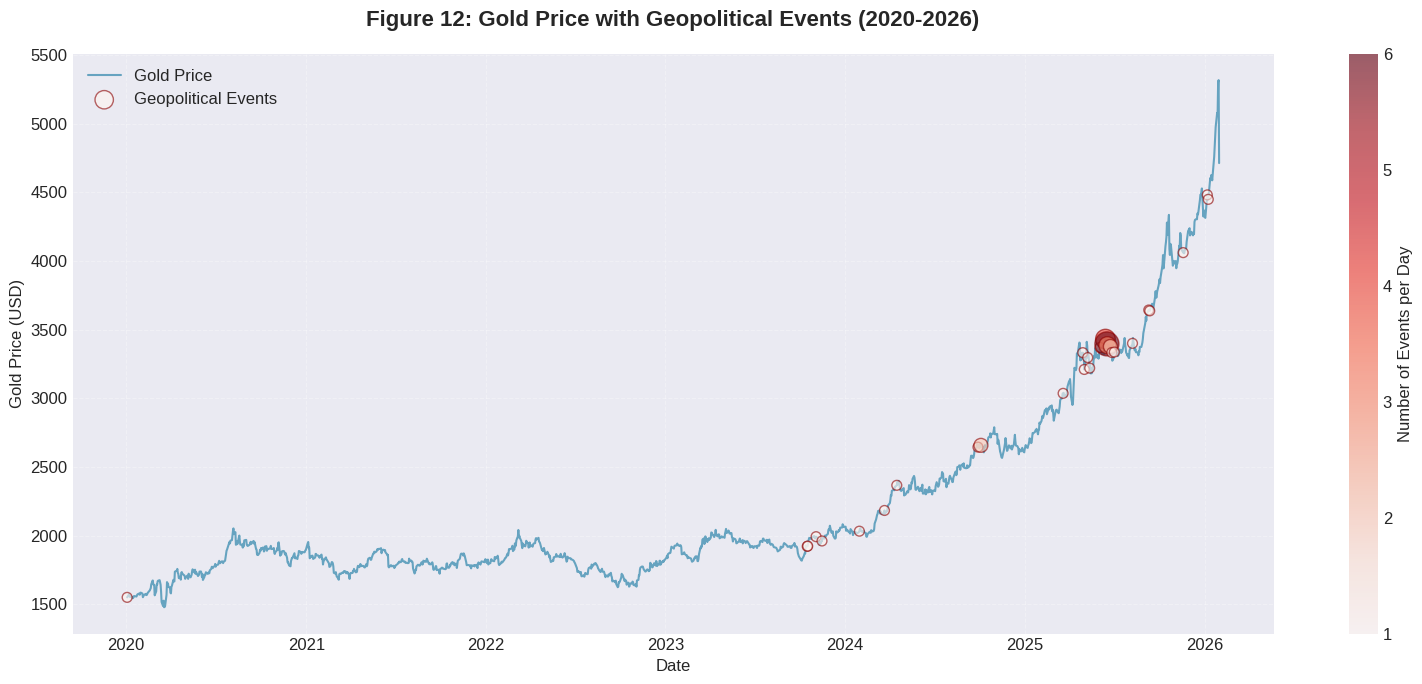

In [ ]:

#5.2 Event Impact on Gold Prices

# FIGURE 12: Gold Price with Event Markers
fig, ax = plt.subplots(figsize=(16, 7))

# Plot gold price
ax.plot(merged_df['Date'], merged_df['Close'], linewidth=1.5, color='#2E86AB', alpha=0.7, label='Gold Price')

# Mark events with different sizes based on event count
event_days = merged_df[merged_df['has_event'] == 1]
if len(event_days) > 0:
    scatter = ax.scatter(event_days['Date'], event_days['Close'],
                         c=event_days['event_count'], s=event_days['event_count']*50,
                         cmap='Reds', alpha=0.6, edgecolors='darkred', linewidth=1,
                         label='Geopolitical Events', zorder=5)

    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Number of Events per Day')

ax.set_title('Figure 12: Gold Price with Geopolitical Events (2020-2026)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Gold Price (USD)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('fig12_gold_with_events.png', dpi=300, bbox_inches='tight')
plt.show()

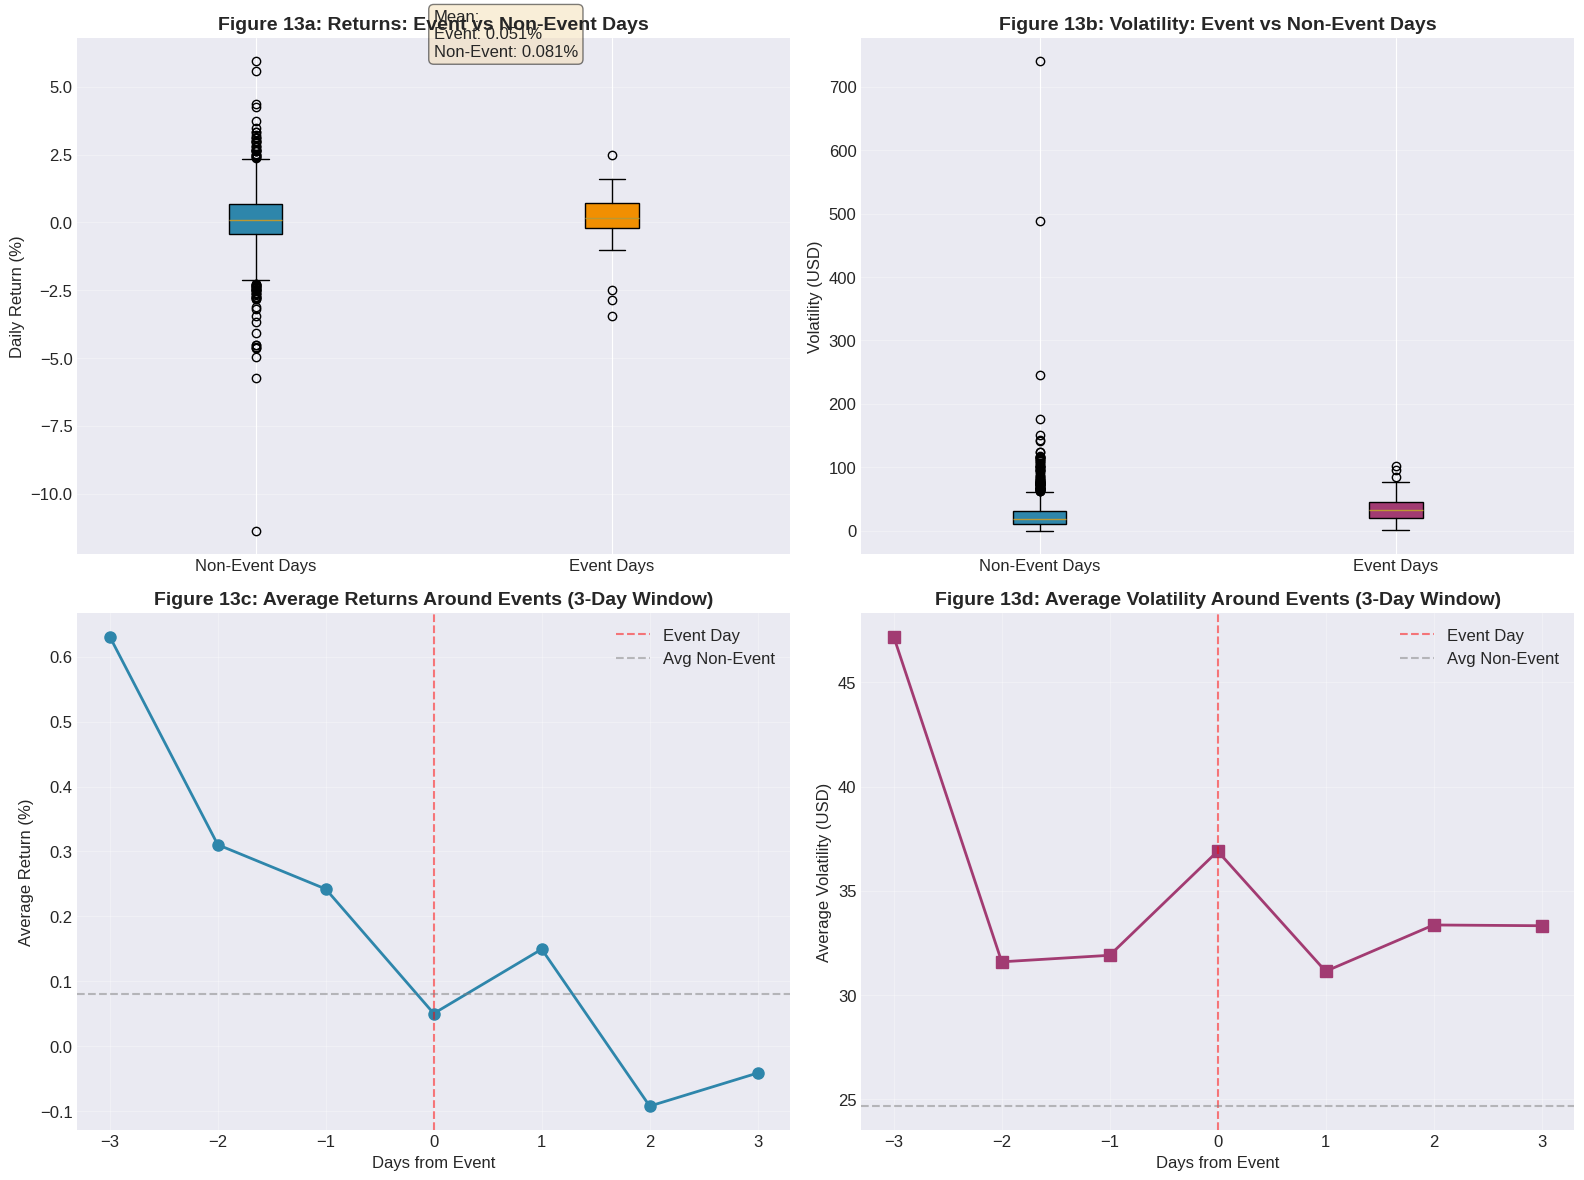

In [ ]:

# FIGURE 13: Event Impact Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 13a: Returns on event vs non-event days
event_returns = merged_df[merged_df['has_event']==1]['Daily_Return'] * 100
non_event_returns = merged_df[merged_df['has_event']==0]['Daily_Return'] * 100

box_data = [non_event_returns.dropna(), event_returns.dropna()]
bp = axes[0,0].boxplot(box_data, labels=['Non-Event Days', 'Event Days'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2E86AB')
bp['boxes'][1].set_facecolor('#F18F01')
axes[0,0].set_title('Figure 13a: Returns: Event vs Non-Event Days', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Daily Return (%)')
axes[0,0].grid(True, alpha=0.3, axis='y')

# Add statistics
stats_text = f"Mean:\nEvent: {event_returns.mean():.3f}%\nNon-Event: {non_event_returns.mean():.3f}%"
axes[0,0].text(1.5, axes[0,0].get_ylim()[1]*0.9, stats_text,
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 13b: Volatility on event vs non-event days
event_vol = merged_df[merged_df['has_event']==1]['Volatility']
non_event_vol = merged_df[merged_df['has_event']==0]['Volatility']

box_data2 = [non_event_vol.dropna(), event_vol.dropna()]
bp2 = axes[0,1].boxplot(box_data2, labels=['Non-Event Days', 'Event Days'], patch_artist=True)
bp2['boxes'][0].set_facecolor('#2E86AB')
bp2['boxes'][1].set_facecolor('#A23B72')
axes[0,1].set_title('Figure 13b: Volatility: Event vs Non-Event Days', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Volatility (USD)')
axes[0,1].grid(True, alpha=0.3, axis='y')

# 13c: Event window analysis (3-day window around events)
window_days = [-3, -2, -1, 0, 1, 2, 3]
window_returns = []
window_volatility = []

event_dates = merged_df[merged_df['has_event']==1]['Date'].values[:50]  # First 50 events

if len(event_dates) > 0:
    for days in window_days:
        shifted_dates = [d + pd.Timedelta(days=days) for d in event_dates]
        returns = []
        vols = []
        for date in shifted_dates:
            match = merged_df[merged_df['Date'] == date]
            if not match.empty:
                returns.append(match['Daily_Return'].values[0] * 100)
                vols.append(match['Volatility'].values[0])
        window_returns.append(np.mean(returns) if returns else 0)
        window_volatility.append(np.mean(vols) if vols else 0)

    axes[1,0].plot(window_days, window_returns, marker='o', linewidth=2, markersize=8, color='#2E86AB')
    axes[1,0].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Event Day')
    axes[1,0].axhline(y=non_event_returns.mean(), color='gray', linestyle='--', alpha=0.5, label='Avg Non-Event')
    axes[1,0].set_title('Figure 13c: Average Returns Around Events (3-Day Window)', fontsize=14, fontweight='bold')
    axes[1,0].set_xlabel('Days from Event')
    axes[1,0].set_ylabel('Average Return (%)')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    axes[1,0].set_xticks(window_days)

    # 13d: Volatility around events
    axes[1,1].plot(window_days, window_volatility, marker='s', linewidth=2, markersize=8, color='#A23B72')
    axes[1,1].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Event Day')
    axes[1,1].axhline(y=non_event_vol.mean(), color='gray', linestyle='--', alpha=0.5, label='Avg Non-Event')
    axes[1,1].set_title('Figure 13d: Average Volatility Around Events (3-Day Window)', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('Days from Event')
    axes[1,1].set_ylabel('Average Volatility (USD)')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)
    axes[1,1].set_xticks(window_days)
else:
    axes[1,0].text(0.5, 0.5, 'Insufficient event data', ha='center', va='center')
    axes[1,1].text(0.5, 0.5, 'Insufficient event data', ha='center', va='center')

plt.tight_layout()
plt.savefig('fig13_event_impact_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

print("="*80)
print("EVENT IMPACT STATISTICS")
print("="*80)

print("\nRETURN ANALYSIS:")
print(f"   • Event days mean return: {event_returns.mean():.3f}%")
print(f"   • Non-event days mean return: {non_event_returns.mean():.3f}%")
print(f"   • Difference: {event_returns.mean() - non_event_returns.mean():.3f}%")
if len(event_returns) > 0 and len(non_event_returns) > 0:
    t_stat, p_value = stats.ttest_ind(event_returns.dropna(), non_event_returns.dropna())
    print(f"   • T-test p-value: {p_value:.4f}")

print("\nVOLATILITY ANALYSIS:")
print(f"   • Event days mean volatility: ${event_vol.mean():.2f}")
print(f"   • Non-event days mean volatility: ${non_event_vol.mean():.2f}")
print(f"   • Difference: ${event_vol.mean() - non_event_vol.mean():.2f} ({(event_vol.mean()/non_event_vol.mean()-1)*100:.1f}% higher)")
if len(event_vol) > 0 and len(non_event_vol) > 0:
    t_stat2, p_value2 = stats.ttest_ind(event_vol.dropna(), non_event_vol.dropna())
    print(f"   • T-test p-value: {p_value2:.4f}")

if len(window_returns) > 0:
    print("\nEVENT WINDOW ANALYSIS:")
    print(f"   • Day -3 (before): Return: {window_returns[0]:.3f}%, Vol: ${window_volatility[0]:.2f}")
    print(f"   • Day 0 (event):   Return: {window_returns[3]:.3f}%, Vol: ${window_volatility[3]:.2f}")
    print(f"   • Day +3 (after):  Return: {window_returns[6]:.3f}%, Vol: ${window_volatility[6]:.2f}")

EVENT IMPACT STATISTICS

RETURN ANALYSIS:
   • Event days mean return: 0.051%
   • Non-event days mean return: 0.081%
   • Difference: -0.030%
   • T-test p-value: 0.8884

VOLATILITY ANALYSIS:
   • Event days mean volatility: $36.90
   • Non-event days mean volatility: $24.67
   • Difference: $12.23 (49.6% higher)
   • T-test p-value: 0.0375

EVENT WINDOW ANALYSIS:
   • Day -3 (before): Return: 0.630%, Vol: $47.19
   • Day 0 (event):   Return: 0.051%, Vol: $36.90
   • Day +3 (after):  Return: -0.041%, Vol: $33.32


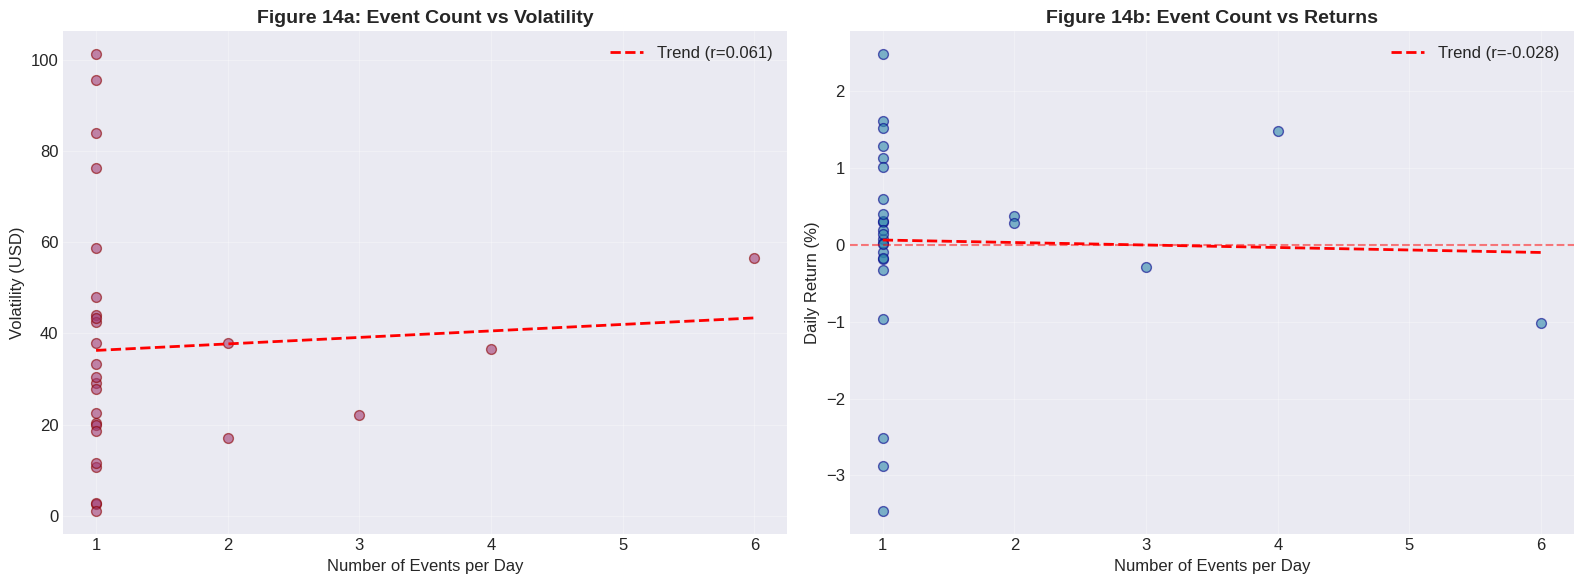

In [ ]:

#5.3 Correlation Between News Volume and Market Metrics

# FIGURE 14: News Volume vs Market Metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 14a: Event count vs Volatility
event_days_only = merged_df[merged_df['has_event'] == 1]
if len(event_days_only) > 1:
    axes[0].scatter(event_days_only['event_count'], event_days_only['Volatility'],
                    alpha=0.6, s=50, color='#A23B72', edgecolors='darkred')
    axes[0].set_xlabel('Number of Events per Day')
    axes[0].set_ylabel('Volatility (USD)')
    axes[0].set_title('Figure 14a: Event Count vs Volatility', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    # Add trend line
    z = np.polyfit(event_days_only['event_count'], event_days_only['Volatility'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(event_days_only['event_count'].min(), event_days_only['event_count'].max(), 100)
    corr_val = event_days_only[['event_count', 'Volatility']].corr().iloc[0,1]
    axes[0].plot(x_range, p(x_range), "r--", linewidth=2,
                label=f'Trend (r={corr_val:.3f})')
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
    axes[0].set_title('Figure 14a: Event Count vs Volatility', fontsize=14, fontweight='bold')

# 14b: Event count vs Returns
if len(event_days_only) > 1:
    axes[1].scatter(event_days_only['event_count'], event_days_only['Daily_Return']*100,
                    alpha=0.6, s=50, color='#2E86AB', edgecolors='darkblue')
    axes[1].set_xlabel('Number of Events per Day')
    axes[1].set_ylabel('Daily Return (%)')
    axes[1].set_title('Figure 14b: Event Count vs Returns', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)

    # Add trend line
    z = np.polyfit(event_days_only['event_count'], event_days_only['Daily_Return']*100, 1)
    p = np.poly1d(z)
    x_range = np.linspace(event_days_only['event_count'].min(), event_days_only['event_count'].max(), 100)
    corr_val = event_days_only[['event_count', 'Daily_Return']].corr().iloc[0,1]
    axes[1].plot(x_range, p(x_range), "r--", linewidth=2,
                label=f'Trend (r={corr_val:.3f})')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
    axes[1].set_title('Figure 14b: Event Count vs Returns', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('fig14_news_volume_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

print("="*80)
print("NEWS VOLUME CORRELATION")
print("="*80)

if len(event_days_only) > 1:
    vol_corr = event_days_only[['event_count', 'Volatility']].corr().iloc[0,1]
    ret_corr = event_days_only[['event_count', 'Daily_Return']].corr().iloc[0,1]

    print(f"\nCorrelation between Event Count and:")
    print(f"   • Volatility: {vol_corr:.3f}")
    print(f"   • Returns: {ret_corr:.3f}")

    print(f"\nDays with multiple events:")
    multi_event_days = event_days_only[event_days_only['event_count'] > 1]
    print(f"   • {len(multi_event_days)} days with 2+ events")
    if len(multi_event_days) > 0:
        print(f"   • Avg volatility on multi-event days: ${multi_event_days['Volatility'].mean():.2f}")
        print(f"   • Avg return on multi-event days: {multi_event_days['Daily_Return'].mean()*100:.3f}%")
else:
    print("\nInsufficient event days for correlation analysis")

NEWS VOLUME CORRELATION

Correlation between Event Count and:
   • Volatility: 0.061
   • Returns: -0.028

Days with multiple events:
   • 5 days with 2+ events
   • Avg volatility on multi-event days: $34.10
   • Avg return on multi-event days: 0.170%


In [ ]:

#6. KEY FINDINGS SUMMARY

print("="*80)
print("COMPREHENSIVE FINDINGS SUMMARY")
print("="*80)

print("""
 PRIMARY DATA (GOLD) KEY FINDINGS:
----------------------------------------""")
print(f"""
1. PRICE TREND:
   • Start (2020): ${gold_df['Close'].iloc[0]:,.2f}
   • End (2026): ${gold_df['Close'].iloc[-1]:,.2f}
   • Total Increase: {(gold_df['Close'].iloc[-1]/gold_df['Close'].iloc[0] - 1)*100:.1f}%
   • Average Price: ${gold_df['Close'].mean():,.2f}
   • Record High: ${gold_df['Close'].max():,.2f} ({gold_df.loc[gold_df['Close'].idxmax(), 'Date'].strftime('%Y-%m-%d')})

2. VOLATILITY:
   • Average Daily Volatility: ${gold_df['Volatility'].mean():.2f}
   • Most Volatile Day: ${gold_df['Volatility'].max():,.2f} ({gold_df.loc[gold_df['Volatility'].idxmax(), 'Date'].strftime('%Y-%m-%d')})
   • Volatility Spikes: COVID-19 (2020), Ukraine War (2022), Israel-Gaza (2023), Jan 2026

3. RETURNS:
   • Average Daily Return: {gold_df['Daily_Return'].mean()*100:.3f}%
   • Standard Deviation: {gold_df['Daily_Return'].std()*100:.3f}%
   • Positive Days: {(gold_df['Daily_Return'] > 0).mean()*100:.1f}%
   • Negative Days: {(gold_df['Daily_Return'] < 0).mean()*100:.1f}%
   • Most Extreme Return: {gold_df.loc[abs(gold_df['Daily_Return']).idxmax(), 'Daily_Return']*100:.2f}%
     ({gold_df.loc[abs(gold_df['Daily_Return']).idxmax(), 'Date'].strftime('%Y-%m-%d')})

4. CORRELATIONS:
   • Price vs Volatility: {corr_matrix.loc['Close', 'Volatility']:.3f}
   • Returns vs Volatility: {corr_matrix.loc['Daily_Return', 'Volatility']:.3f}

5. ANOMALIES:
   • Total Anomaly Days: {len(anomalies)} ({(len(anomalies)/len(gold_df))*100:.1f}% of data)
   • Most Extreme: {anomalies.loc[anomalies['Volatility_Zscore'].idxmax(), 'Date'].strftime('%Y-%m-%d')}
""")

COMPREHENSIVE FINDINGS SUMMARY

 PRIMARY DATA (GOLD) KEY FINDINGS:
----------------------------------------

1. PRICE TREND:
   • Start (2020): $1,549.20
   • End (2026): $4,713.90
   • Total Increase: 204.3%
   • Average Price: $2,225.79
   • Record High: $5,318.40 (2026-01-29)

2. VOLATILITY:
   • Average Daily Volatility: $24.89
   • Most Volatile Day: $740.50 (2026-01-30)
   • Volatility Spikes: COVID-19 (2020), Ukraine War (2022), Israel-Gaza (2023), Jan 2026

3. RETURNS:
   • Average Daily Return: 0.080%
   • Standard Deviation: 1.124%
   • Positive Days: 55.7%
   • Negative Days: 44.1%
   • Most Extreme Return: -11.37% 
     (2026-01-30)

4. CORRELATIONS:
   • Price vs Volatility: 0.432
   • Returns vs Volatility: -0.187

5. ANOMALIES:
   • Total Anomaly Days: 91 (6.0% of data)
   • Most Extreme: 2026-01-30



In [ ]:

print("""
 SECONDARY DATA (NEWS) KEY FINDINGS:
------------------------------------------""")
print(f"""
1. NEWS VOLUME:
   • Total Articles: {len(news_df)}
   • Geopolitical Events: {news_df['event_indicator'].sum()} ({news_df['event_indicator'].mean()*100:.1f}%)
   • Most Active Month: {monthly_counts.idxmax()} ({monthly_counts.max()} articles)
   • Most Active Year: {yearly_total.idxmax()} ({yearly_total.max()} articles)

2. EVENT TYPES:
   • Most Common: {geo_news['event_type'].value_counts().index[0] if len(geo_news) > 0 else 'N/A'}
   • Trending Topics: {', '.join([w[0] for w in word_counts[:5]])}
""")

print("""
 INTEGRATED ANALYSIS KEY FINDINGS:
----------------------------------------""")
if len(event_days_only) > 0:
    print(f"""
1. EVENT IMPACT:
   • Event Day Returns: {event_returns.mean():.3f}% vs Non-Event: {non_event_returns.mean():.3f}%
   • Event Day Volatility: ${event_vol.mean():.2f} vs Non-Event: ${non_event_vol.mean():.2f}
   • Volatility Increase: {(event_vol.mean()/non_event_vol.mean()-1)*100:.1f}% higher on event days

2. EVENT WINDOW:
   • Pre-Event (Day -1): Return {window_returns[2] if len(window_returns)>2 else 0:.3f}%, Vol ${window_volatility[2] if len(window_volatility)>2 else 0:.2f}
   • Event Day (Day 0): Return {window_returns[3] if len(window_returns)>3 else 0:.3f}%, Vol ${window_volatility[3] if len(window_volatility)>3 else 0:.2f}
   • Post-Event (Day +1): Return {window_returns[4] if len(window_returns)>4 else 0:.3f}%, Vol ${window_volatility[4] if len(window_volatility)>4 else 0:.2f}

3. NEWS VOLUME CORRELATION:
   • Events vs Volatility: {vol_corr if len(event_days_only)>1 else 0:.3f}
   • Events vs Returns: {ret_corr if len(event_days_only)>1 else 0:.3f}
    """)
else:
    print("\n⚠️ Insufficient event data for integrated analysis")

print("""
 HYPOTHESES GENERATED:
-------------------------
1. Geopolitical events cause immediate volatility spikes in gold prices
2. Event days show higher volatility but not necessarily directional returns
3. Multiple events on same day amplify market reaction
4. Market reactions vary by event type (wars > trade tensions)
5. There is a 1-2 day delayed reaction pattern for some events
6. Recent years show amplified sensitivity to geopolitical tensions

NEXT STEPS:
--------------
1. Quantify event impact magnitude by event type
2. Analyze reaction time patterns (immediate vs delayed)
3. Build predictive model for event-based price movements
4. Compare monetary policy vs geopolitical event impacts
""")

print("\n" + "="*80)
print(" EDA COMPLETED SUCCESSFULLY!")
print("="*80)


 SECONDARY DATA (NEWS) KEY FINDINGS:
------------------------------------------

1. NEWS VOLUME:
   • Total Articles: 76
   • Geopolitical Events: 50 (65.8%)
   • Most Active Month: 2025-06 (25 articles)
   • Most Active Year: 2025 (51 articles)

2. EVENT TYPES:
   • Most Common: War/Conflict 
   • Trending Topics: gold, the, prices, geopolitical, conflict


 INTEGRATED ANALYSIS KEY FINDINGS:
----------------------------------------

1. EVENT IMPACT:
   • Event Day Returns: 0.051% vs Non-Event: 0.081%
   • Event Day Volatility: $36.90 vs Non-Event: $24.67
   • Volatility Increase: 49.6% higher on event days

2. EVENT WINDOW:
   • Pre-Event (Day -1): Return 0.242%, Vol $31.90
   • Event Day (Day 0): Return 0.051%, Vol $36.90
   • Post-Event (Day +1): Return 0.150%, Vol $31.14

3. NEWS VOLUME CORRELATION:
   • Events vs Volatility: 0.061
   • Events vs Returns: -0.028
    

 HYPOTHESES GENERATED:
-------------------------
1. Geopolitical events cause immediate volatility spikes in gold 

In [ ]:

# Save processed data
gold_df.to_csv('gold_eda_processed.csv', index=False)
news_df.to_csv('news_eda_processed.csv', index=False)
merged_df.to_csv('merged_gold_news.csv', index=False)

print(" Processed data saved:")
print("   • gold_eda_processed.csv")
print("   • news_eda_processed.csv")
print("   • merged_gold_news.csv")

 Processed data saved:
   • gold_eda_processed.csv
   • news_eda_processed.csv
   • merged_gold_news.csv
